# EDA — Multimodal3DIdent (manifiesto `m3di_test.parquet`)

Análisis exploratorio del split de **test** tal como quedó en el manifiesto
(`data/manifests/m3di_test.parquet`), que es la fuente de verdad del pipeline de evaluación.
El objetivo no es describir el dataset en abstracto, sino **verificar los supuestos de los que
depende la métrica de fidelidad**:

| # | Pregunta | Por qué importa |
|---|---|---|
| 1 | ¿El manifiesto está completo y alineado (imagen ↔ latentes ↔ caption)? | Un desfase de índice invalida toda la evaluación |
| 2 | ¿Latentes de imagen y de texto coinciden? | Define el techo alcanzable por atributo |
| 3 | ¿Qué código de `xpos`/`ypos` es izquierda/derecha, arriba/abajo **en la imagen**? | El extractor traduce palabras a códigos; si el mapeo está invertido, la exactitud se invierte |
| 4 | ¿Qué es `object_color`? ¿Cómo se relaciona con el nombre citado en el caption y con el píxel? | Decide cómo se evalúa el color (nombre exacto, término básico, ΔE) |
| 5 | ¿Hay dependencias entre atributos (atajos) o desbalance? | Define las líneas base de azar y la validez de la exactitud macro |
| 6 | ¿Test se parece a train/val? | Condiciona la lectura de la Etapa 2 (fine-tuning) |

Todas las cifras que aparecen en la sección final se **calculan**; el notebook no asume
ningún mapeo (código→palabra, código→lado de la imagen): los **induce** de los datos.

Salidas: figuras en `reports/figures/eda/`, tablas en `reports/tables/eda/` y un resumen
`reports/tables/eda/hallazgos_<split>.md`.

In [1]:
from __future__ import annotations

import os
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from PIL import Image
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

## 0. Configuración

In [2]:
def _find_root() -> Path:
    if os.environ.get("M3DI_ROOT"):
        return Path(os.environ["M3DI_ROOT"]).resolve()
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "data" / "manifests").is_dir():
            return p
    return here


ROOT = _find_root()
SPLIT = os.environ.get("M3DI_SPLIT", "test")
SPLITS_CMP = ["train", "val"]  # se comparan contra SPLIT si existen
MANIFEST_DIR = ROOT / "data" / "manifests"
# Rutas alternativas por si image_path del manifiesto quedó obsoleto tras reorganizar el repo
IMG_FALLBACK_DIRS = [
    ROOT / "data" / "raw" / "m3di" / SPLIT / "images",
    ROOT / "data" / "m3di" / SPLIT / "images",
]
FIG_DIR = ROOT / "reports" / "figures" / "eda"
TAB_DIR = ROOT / "reports" / "tables" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

N_IMG_SAMPLE = int(os.environ.get("M3DI_N_IMG", 2000))  # imágenes analizadas a nivel de píxel
SEED = 0
rng = np.random.default_rng(SEED)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

FINDINGS: list[tuple[str, str]] = []


def note(section: str, text: str) -> None:
    """Registra un hallazgo cuantitativo para el resumen final."""
    FINDINGS.append((section, text))
    print(f"[{section}] {text}")


def savefig(fig, name: str) -> None:
    fig.savefig(FIG_DIR / f"{SPLIT}_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print("ROOT        :", ROOT)
print("manifiestos :", sorted(p.name for p in MANIFEST_DIR.glob("*.parquet")))

ROOT        : /mnt/home2/t7-vLLM/Multimodal_LLM
manifiestos : ['m3di_base_test.parquet', 'm3di_base_train.parquet', 'm3di_base_val.parquet']


### Utilidades: color, círculo de matiz y teoría de la información

El matiz vive en $\mathbb{S}^1 \cong [0,1)$, por lo que las diferencias se toman como
$d(a,b) = \big((a-b+\tfrac12) \bmod 1\big) - \tfrac12 \in [-\tfrac12, \tfrac12)$ y la media
como $\bar h = \frac{1}{2\pi}\arg \sum_i e^{2\pi i h_i}$.
La conversión sRGB→CIELAB usa iluminante D65; $\Delta E_{76}$ es la distancia euclidiana en Lab.

Para atributos discretos $A, B$ con $n$ observaciones:
$H(A) = -\sum_a p_a \log_2 p_a$, $\; I(A;B) = \sum_{a,b} p_{ab}\log_2\frac{p_{ab}}{p_a p_b}$,
e información mutua normalizada $\mathrm{NMI} = I(A;B)/\min\{H(A),H(B)\}$.
Bajo independencia, $G = 2n\ln 2\cdot \hat I(A;B) \sim \chi^2_{(K_A-1)(K_B-1)}$ (test G), y el
sesgo positivo del estimador plug-in es $\approx (K_A-1)(K_B-1)/(2n\ln 2)$ bits (Miller–Madow).

In [3]:
def circ_diff(a, b):
    return (np.asarray(a, float) - np.asarray(b, float) + 0.5) % 1.0 - 0.5


def circ_mean(h):
    h = np.asarray(h, float)
    return (np.angle(np.exp(2j * np.pi * h).mean()) / (2 * np.pi)) % 1.0


def circ_std(h):
    R = np.abs(np.exp(2j * np.pi * np.asarray(h, float)).mean())
    return np.sqrt(-2 * np.log(max(R, 1e-12))) / (2 * np.pi)


def srgb_to_lab(rgb):
    rgb = np.asarray(rgb, float)
    lin = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
    M = np.array([[0.4124564, 0.3575761, 0.1804375],
                  [0.2126729, 0.7151522, 0.0721750],
                  [0.0193339, 0.1191920, 0.9503041]])
    xyz = lin @ M.T / np.array([0.95047, 1.0, 1.08883])
    e = (6 / 29) ** 3
    f = np.where(xyz > e, np.cbrt(xyz), xyz / (3 * (6 / 29) ** 2) + 4 / 29)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]),
                     200 * (f[..., 1] - f[..., 2])], axis=-1)


def hsv_to_rgb(h, s, v):
    return mcolors.hsv_to_rgb(np.stack(np.broadcast_arrays(h, s, v), axis=-1))


def entropy_bits(x) -> float:
    _, c = np.unique(np.asarray(x), return_counts=True)
    p = c / c.sum()
    return float(-(p * np.log2(p)).sum())


def mutual_info_bits(a, b):
    """I(A;B) en bits, test G y sesgo de Miller–Madow."""
    _, ia = np.unique(np.asarray(a), return_inverse=True)
    _, ib = np.unique(np.asarray(b), return_inverse=True)
    n = len(ia)
    tab = np.zeros((ia.max() + 1, ib.max() + 1))
    np.add.at(tab, (ia, ib), 1)
    p = tab / n
    pa, pb = p.sum(1, keepdims=True), p.sum(0, keepdims=True)
    nz = p > 0
    mi = float((p[nz] * np.log2(p[nz] / (pa @ pb)[nz])).sum())
    dof = (tab.shape[0] - 1) * (tab.shape[1] - 1)
    G = 2 * n * np.log(2) * mi
    pval = float(stats.chi2.sf(G, dof)) if dof > 0 else 1.0
    bias = dof / (2 * n * np.log(2))
    return mi, pval, bias


def jsd_bits(x, y) -> float:
    """Divergencia de Jensen–Shannon entre las distribuciones empíricas de x e y."""
    cats = np.union1d(np.unique(x), np.unique(y))
    px = np.array([(np.asarray(x) == c).mean() for c in cats])
    py = np.array([(np.asarray(y) == c).mean() for c in cats])
    m = 0.5 * (px + py)

    def kl(p, q):
        nz = p > 0
        return float((p[nz] * np.log2(p[nz] / q[nz])).sum())

    return 0.5 * kl(px, m) + 0.5 * kl(py, m)


def quantile_bins(x, k=8):
    x = np.asarray(x, float)
    edges = np.unique(np.quantile(x, np.linspace(0, 1, k + 1)[1:-1]))
    return np.digitize(x, edges)


def hue_bins(h, k=12):
    return (np.floor((np.asarray(h, float) % 1.0) * k).astype(int)) % k

## 1. Carga, esquema e integridad del manifiesto

In [4]:
path = MANIFEST_DIR / f"m3di_base_{SPLIT}.parquet"
df = pl.read_parquet(path)
N = df.height
print(f"{path.name}: {N} filas × {df.width} columnas\n")
for c, t in df.schema.items():
    print(f"  {c:28s} {t}")


def pick(*cands):
    return next((c for c in cands if c in df.columns), None)


# `build_manifest.py` prefija con `text_` las columnas de latents_text.csv, salvo las que ya
# empiezan por `text_` (de ahí que la plantilla quede como `text_phrasing`). Se toleran ambas.
C = {
    "id": pick("image_id"), "img": pick("image_path"), "row": pick("row_idx"),
    "caption": pick("caption_ref", "caption"),
    "shape": pick("object_shape"), "x": pick("object_xpos"), "y": pick("object_ypos"),
    "z": pick("object_zpos"),
    "rot_a": pick("object_alpharot"), "rot_b": pick("object_betarot"), "rot_g": pick("object_gammarot"),
    "color": pick("object_color"), "spot_pos": pick("spotlight_pos"),
    "spot_color": pick("spotlight_color"), "bg_color": pick("background_color"),
    "t_shape": pick("text_object_shape"), "t_x": pick("text_object_xpos"),
    "t_y": pick("text_object_ypos"), "t_z": pick("text_object_zpos"),
    "cname": pick("text_object_color_name", "object_color_name"),
    "cidx": pick("text_object_color_index", "object_color_index"),
    "phrasing": pick("text_phrasing", "text_text_phrasing"),
}
missing = [k for k, v in C.items() if v is None]
print("\ncolumnas esperadas no encontradas:", missing or "ninguna")
A = {k: df[v].to_numpy() for k, v in C.items() if v is not None}

m3di_base_test.parquet: 10000 filas × 25 columnas

  id                           String
  image_id                     String
  image_path                   String
  caption_ref                  String
  split                        String
  variant                      String
  row_idx                      UInt32
  object_shape                 Int64
  object_xpos                  Int64
  object_ypos                  Int64
  object_zpos                  Float64
  object_alpharot              Float64
  object_betarot               Float64
  object_gammarot              Float64
  object_color                 Float64
  spotlight_pos                Float64
  spotlight_color              Float64
  background_color             Float64
  text_object_shape            Int64
  text_object_xpos             Int64
  text_object_ypos             Int64
  text_object_zpos             Float64
  text_object_color_name       String
  text_object_color_index      Int64
  text_text_phrasing           Int6

In [5]:
# Nulos y NaN
nul = {c: df[c].null_count() for c in df.columns}
nan = {c: int(df[c].is_nan().sum()) for c, t in df.schema.items() if t in (pl.Float32, pl.Float64)}
bad = {c: (nul[c], nan.get(c, 0)) for c in df.columns if nul[c] or nan.get(c, 0)}
print("nulos / NaN por columna:", bad or "ninguno")
note("Integridad", f"{N} filas, {df.width} columnas; nulos/NaN: {'ninguno' if not bad else bad}.")

# Unicidad e índice
if C["id"]:
    n_ids = df[C["id"]].n_unique()
    note("Integridad", f"image_id únicos: {n_ids}/{N}" + (" ✓" if n_ids == N else " ✗ DUPLICADOS"))
if C["row"]:
    contiguous = bool(np.array_equal(np.sort(A["row"]), np.arange(N)))
    ordered = bool(np.array_equal(A["row"], np.arange(N)))
    note("Integridad", f"row_idx contiguo 0..N-1: {contiguous}; en orden: {ordered}.")
if C["id"] and C["row"]:
    num = np.array([int(re.sub(r"\D", "", s) or -1) for s in df[C["id"]].to_list()])
    mono = bool(np.all(np.diff(num[np.argsort(A["row"])]) > 0))
    note("Integridad", f"número del archivo de imagen crece con row_idx: {mono} "
                      "(condición para la alineación imagen↔fila).")

caps = df[C["caption"]].to_list()
n_cap_u = len(set(caps))
note("Integridad", f"captions únicos: {n_cap_u}/{N} ({n_cap_u / N:.1%}); "
                  "las repeticiones son esperables en texto generado por plantillas.")

nulos / NaN por columna: ninguno
[Integridad] 10000 filas, 25 columnas; nulos/NaN: ninguno.
[Integridad] image_id únicos: 10000/10000 ✓
[Integridad] row_idx contiguo 0..N-1: True; en orden: True.
[Integridad] número del archivo de imagen crece con row_idx: True (condición para la alineación imagen↔fila).
[Integridad] captions únicos: 5385/10000 (53.8%); las repeticiones son esperables en texto generado por plantillas.


In [6]:
# Rutas de imagen: el manifiesto guarda rutas absolutas del momento en que se construyó
def resolve_image(i: int) -> Path | None:
    p = Path(df[C["img"]][i]) if C["img"] else None
    if p is not None and p.is_file():
        return p
    name = p.name if p is not None else f"{df[C['id']][i]}.png"
    for d in IMG_FALLBACK_DIRS:
        if (d / name).is_file():
            return d / name
    return None


probe = rng.choice(N, size=min(200, N), replace=False)
found = [resolve_image(int(i)) is not None for i in probe]
direct = [C["img"] is not None and Path(df[C["img"]][int(i)]).is_file() for i in probe]
note("Integridad", f"imágenes accesibles (muestra de {len(probe)}): {np.mean(found):.1%} "
                  f"(vía image_path directo: {np.mean(direct):.1%}).")
IMAGES_OK = np.mean(found) > 0.5

[Integridad] imágenes accesibles (muestra de 200): 100.0% (vía image_path directo: 0.0%).


## 2. Latentes de imagen vs latentes de texto

El caption se genera desde `latents_text.csv`. Si difiere de `latents_image.csv`, ningún modelo
fiel a la imagen puede reproducir a la vez la imagen y el caption: la tasa de desacuerdo es el
techo de la exactitud por atributo medida contra el caption.

In [7]:
dis_rows = []
for a, b in [("shape", "t_shape"), ("x", "t_x"), ("y", "t_y"), ("z", "t_z")]:
    if a in A and b in A:
        dis_rows.append({"atributo": C[a], "desacuerdo": float(np.mean(A[a] != A[b]))})
dis = pl.DataFrame(dis_rows)
print(dis)
dis.write_csv(TAB_DIR / f"{SPLIT}_desacuerdo_imagen_texto.csv")
for r in dis_rows:
    note("Imagen vs texto", f"{r['atributo']}: {r['desacuerdo']:.2%} de desacuerdo.")

shape: (4, 2)
┌──────────────┬────────────┐
│ atributo     ┆ desacuerdo │
│ ---          ┆ ---        │
│ str          ┆ f64        │
╞══════════════╪════════════╡
│ object_shape ┆ 0.0        │
│ object_xpos  ┆ 0.0        │
│ object_ypos  ┆ 0.0        │
│ object_zpos  ┆ 0.0        │
└──────────────┴────────────┘
[Imagen vs texto] object_shape: 0.00% de desacuerdo.
[Imagen vs texto] object_xpos: 0.00% de desacuerdo.
[Imagen vs texto] object_ypos: 0.00% de desacuerdo.
[Imagen vs texto] object_zpos: 0.00% de desacuerdo.


## 3. Latentes continuos: rangos y uniformidad

Test de Kolmogorov–Smirnov contra $\mathcal U(\min,\max)$. Con $n=10^4$ el test detecta
desviaciones mínimas, así que el estadístico $D$ (máxima distancia entre CDFs) es más
informativo que el $p$-valor.

shape: (8, 8)
┌──────────────────┬────────┬────────┬────────┬────────┬──────────┬────────┬────────┐
│ latente          ┆ min    ┆ max    ┆ media  ┆ desv   ┆ n_unicos ┆ KS_D   ┆ KS_p   │
│ ---              ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---      ┆ ---    ┆ ---    │
│ str              ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ i64      ┆ f64    ┆ f64    │
╞══════════════════╪════════╪════════╪════════╪════════╪══════════╪════════╪════════╡
│ object_zpos      ┆ 0.0000 ┆ 0.0000 ┆ 0.0000 ┆ 0.0000 ┆ 1        ┆ NaN    ┆ NaN    │
│ object_alpharot  ┆ 0.0000 ┆ 0.9999 ┆ 0.4978 ┆ 0.2890 ┆ 10000    ┆ 0.0066 ┆ 0.7716 │
│ object_betarot   ┆ 0.0000 ┆ 1.0000 ┆ 0.4965 ┆ 0.2902 ┆ 10000    ┆ 0.0091 ┆ 0.3790 │
│ object_gammarot  ┆ 0.0000 ┆ 1.0000 ┆ 0.4956 ┆ 0.2864 ┆ 10000    ┆ 0.0134 ┆ 0.0555 │
│ object_color     ┆ 0.0002 ┆ 0.9999 ┆ 0.4969 ┆ 0.2919 ┆ 10000    ┆ 0.0108 ┆ 0.1962 │
│ spotlight_pos    ┆ 0.0000 ┆ 0.9999 ┆ 0.5013 ┆ 0.2879 ┆ 10000    ┆ 0.0073 ┆ 0.6601 │
│ spotlight_color  ┆ 0.0000 ┆ 0.9999 ┆ 0

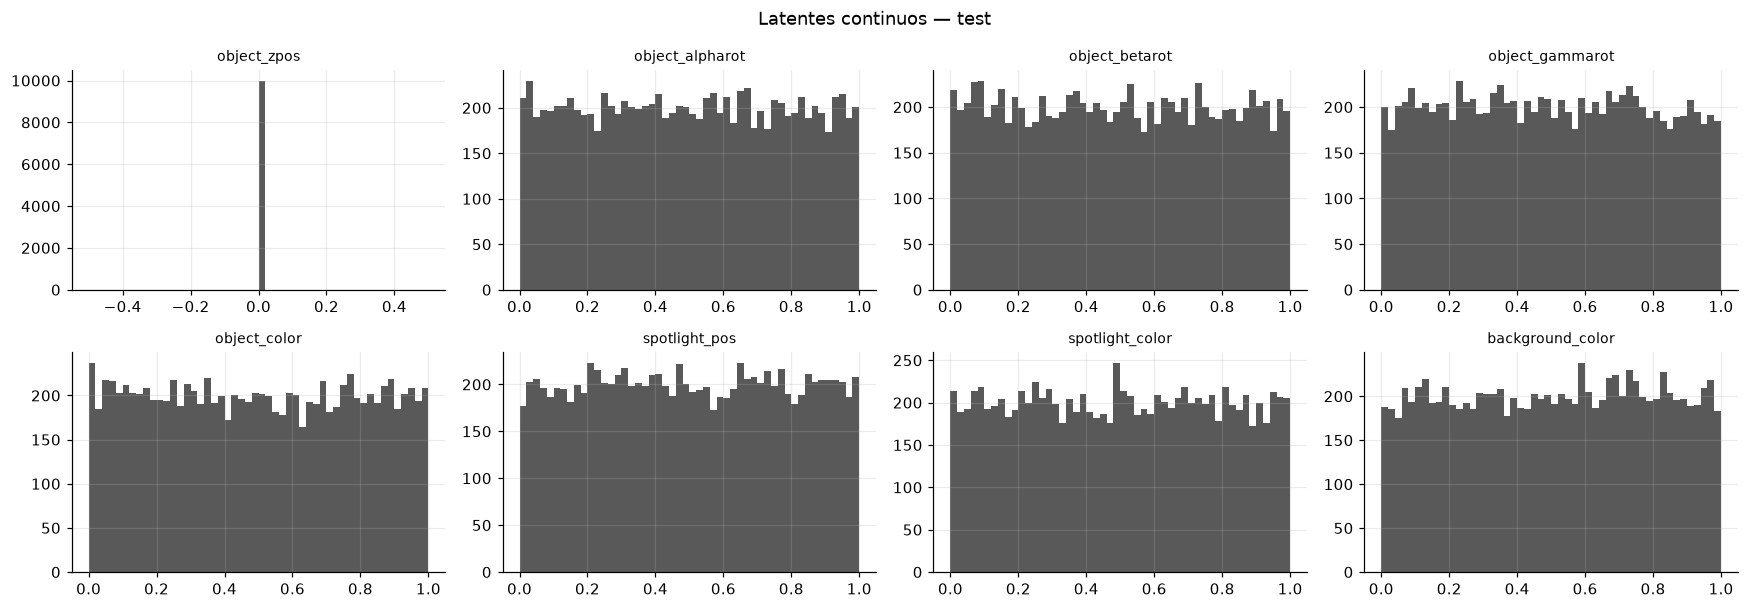

In [8]:
cont_keys = [k for k in ("z", "rot_a", "rot_b", "rot_g", "color", "spot_pos", "spot_color", "bg_color")
             if k in A]
rows = []
for k in cont_keys:
    x = A[k].astype(float)
    lo, hi = float(x.min()), float(x.max())
    D, p = stats.kstest(x, "uniform", args=(lo, hi - lo)) if hi > lo else (np.nan, np.nan)
    rows.append({"latente": C[k], "min": lo, "max": hi, "media": float(x.mean()),
                 "desv": float(x.std()), "n_unicos": int(np.unique(x).size), "KS_D": D, "KS_p": p})
cont = pl.DataFrame(rows)
with pl.Config(tbl_rows=20, float_precision=4, tbl_width_chars=160):
    print(cont)
cont.write_csv(TAB_DIR / f"{SPLIT}_latentes_continuos.csv")

for r in rows:
    if r["n_unicos"] == 1:
        note("Latentes", f"{r['latente']} es constante ({r['min']:.4g}): se excluye de la evaluación.")
hue_like = [r["latente"] for r in rows if r["min"] >= 0 and r["max"] <= 1 and r["n_unicos"] > 1]
note("Latentes", f"latentes en [0,1]: {hue_like}.")
for r in rows:
    if r["n_unicos"] > 1:
        note("Latentes", f"{r['latente']}: rango [{r['min']:.3f}, {r['max']:.3f}], "
                         f"KS D={r['KS_D']:.3f} vs uniforme.")

ncol = 4
nrow = int(np.ceil(len(cont_keys) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.8 * nrow))
for ax, k in zip(np.ravel(axes), cont_keys):
    ax.hist(A[k].astype(float), bins=50, color="0.35")
    ax.set_title(C[k], fontsize=9)
for ax in np.ravel(axes)[len(cont_keys):]:
    ax.axis("off")
fig.suptitle(f"Latentes continuos — {SPLIT}")
fig.tight_layout()
savefig(fig, "latentes_continuos")

## 4. Atributos discretos: forma y posición

Bondad de ajuste a la uniforme ($\chi^2$) y tabla conjunta $x\times y$ con test de independencia.

[Discretos] object_shape: K=7, frecuencias {0: 1402, 1: 1440, 2: 1449, 3: 1406, 4: 1427, 5: 1421, 6: 1455}, min/max = 0.964, χ² uniforme p=0.94.
[Discretos] object_xpos: K=3, frecuencias {0: 3429, 1: 3206, 2: 3365}, min/max = 0.935, χ² uniforme p=0.0192.
[Discretos] object_ypos: K=3, frecuencias {0: 3331, 1: 3392, 2: 3277}, min/max = 0.966, χ² uniforme p=0.37.
[Discretos] x ⟂ y: χ²=5.9, gl=4, p=0.206; celda mín/máx = 1065/1193.


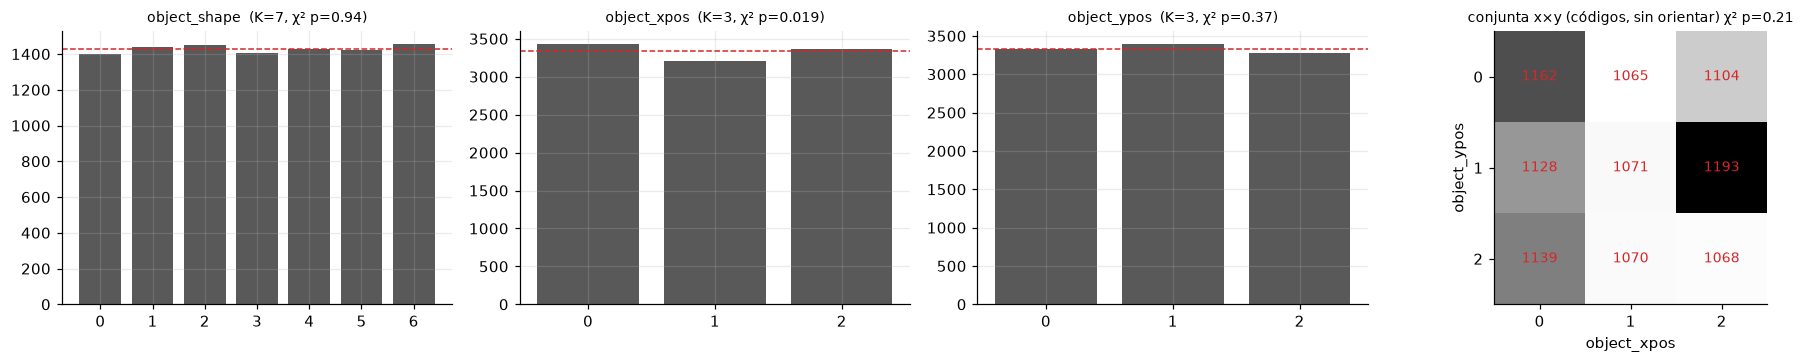

In [9]:
disc_keys = [k for k in ("shape", "x", "y") if k in A]
fig, axes = plt.subplots(1, len(disc_keys) + 1, figsize=(4.2 * (len(disc_keys) + 1), 3.4))
for ax, k in zip(axes, disc_keys):
    vals, cnt = np.unique(A[k], return_counts=True)
    chi2, p = stats.chisquare(cnt)
    ax.bar([str(v) for v in vals], cnt, color="0.35")
    ax.axhline(N / len(vals), ls="--", c="C3", lw=1)
    ax.set_title(f"{C[k]}  (K={len(vals)}, χ² p={p:.2g})", fontsize=9)
    note("Discretos", f"{C[k]}: K={len(vals)}, frecuencias {dict(zip(vals.tolist(), cnt.tolist()))}, "
                      f"min/max = {cnt.min() / cnt.max():.3f}, χ² uniforme p={p:.3g}.")

if "x" in A and "y" in A:
    xs, ys = np.unique(A["x"]), np.unique(A["y"])
    tab = np.array([[np.sum((A["x"] == xv) & (A["y"] == yv)) for xv in xs] for yv in ys])
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    ax = axes[-1]
    im = ax.imshow(tab, cmap="Greys")
    for (i, j), v in np.ndenumerate(tab):
        ax.text(j, i, v, ha="center", va="center", color="C3", fontsize=9)
    ax.set_xticks(range(len(xs)), xs)
    ax.set_yticks(range(len(ys)), ys)
    ax.set_xlabel(C["x"]); ax.set_ylabel(C["y"]); ax.grid(False)
    ax.set_title(f"conjunta x×y (códigos, sin orientar) χ² p={p:.2g}", fontsize=9)
    note("Discretos", f"x ⟂ y: χ²={chi2:.1f}, gl={dof}, p={p:.3g}; celda mín/máx = {tab.min()}/{tab.max()}.")
fig.tight_layout()
savefig(fig, "discretos")

## 5. Vocabulario del caption: inducción del mapeo código → palabra

Para cada código $k$ de un atributo y cada palabra $w$, se calcula
$\mathrm{lift}(w,k) = P(w\mid k)/P(w)$. La palabra que el generador usa para $k$ maximiza el lift
con $P(w\mid k)$ alto. Luego se verifica que la matriz $P(w_j \mid k)$ sea (casi) diagonal:
eso confirma que el caption verbaliza el atributo de forma inyectiva. El contenido entre comillas
(el nombre del color) se elimina antes de tokenizar para que no contamine el vocabulario.


object_xpos:
  0: left (P=1.00, lift=2.9), top (P=0.34, lift=1.0), bottom (P=0.33, lift=1.0)
  1: center (P=1.00, lift=3.1), bottom (P=0.33, lift=1.0), top (P=0.33, lift=1.0)
  2: right (P=1.00, lift=3.0), mid (P=0.35, lift=1.0), top (P=0.33, lift=1.0)
[Caption] object_xpos: mapeo inducido {0: 'left', 1: 'center', 2: 'right'}; inyectivo=True; P(w_k|k) media=1.000, P(w_j|k≠j) media=0.000.

object_ypos:
  0: top (P=1.00, lift=3.0), left (P=0.35, lift=1.0), center (P=0.32, lift=1.0)
  1: mid (P=1.00, lift=2.9), right (P=0.35, lift=1.0), center (P=0.32, lift=1.0)
  2: bottom (P=1.00, lift=3.1), center (P=0.33, lift=1.0), left (P=0.35, lift=1.0)
[Caption] object_ypos: mapeo inducido {0: 'top', 1: 'mid', 2: 'bottom'}; inyectivo=True; P(w_k|k) media=1.000, P(w_j|k≠j) media=0.000.

object_shape:
  0: teapot (P=1.00, lift=7.1), form (P=0.20, lift=1.0)
  1: hare (P=1.00, lift=6.9), form (P=0.19, lift=1.0)
  2: dragon (P=1.00, lift=6.9), form (P=0.18, lift=0.9)
  3: cow (P=1.00, lift=7.1), form 

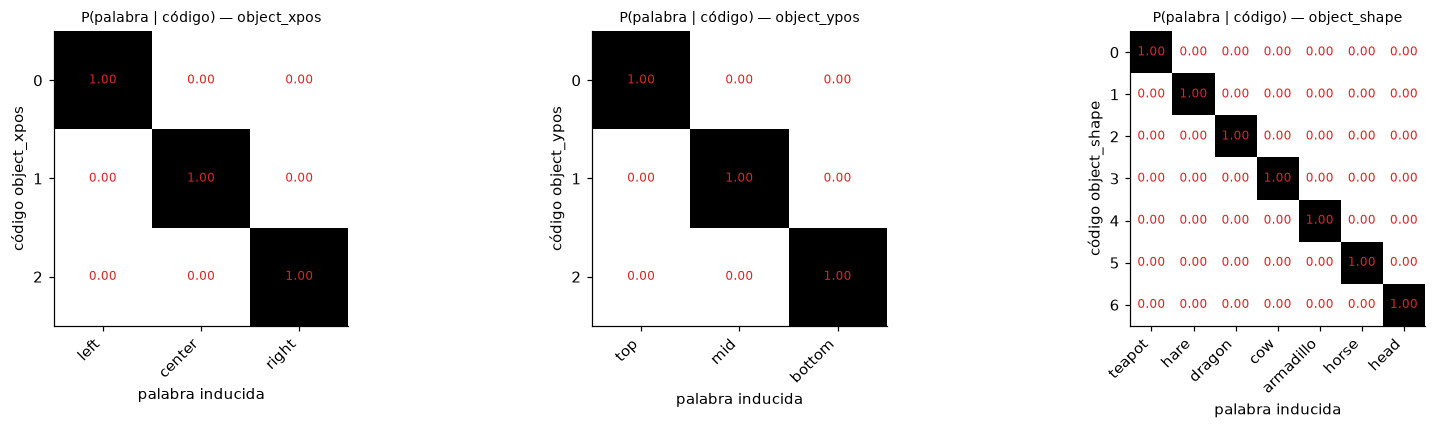

In [10]:
QUOTE_RE = re.compile(r'"([^"]+)"|“([^”]+)”')
TOK_RE = re.compile(r"[a-z]+")
POS_WORDS = {"left", "right", "center", "centre", "central", "middle", "mid", "top", "bottom",
             "upper", "lower", "above", "below"}
STOP = {"a", "an", "the", "is", "are", "of", "in", "on", "at", "to", "and", "with", "this",
        "there", "image", "picture", "scene", "visible", "can", "be", "seen", "shows", "shown",
        "object", "which", "it", "its", "side", "part", "colored", "coloured", "color", "colour",
        "we", "see", "located", "position", "positioned", "placed", "appears", "has", "s"}

caps_l = [c.lower() for c in caps]
toks = [set(TOK_RE.findall(QUOTE_RE.sub(" ", c))) for c in caps_l]
doc_freq = Counter(w for t in toks for w in t)


def induce(codes, vocab=None, exclude=(), min_pw=0.01, top=3):
    codes = np.asarray(codes)
    out = {}
    for k in np.unique(codes):
        idx = np.flatnonzero(codes == k)
        cw = Counter(w for i in idx for w in toks[i])
        cand = []
        for w, c in cw.items():
            if (vocab is not None and w not in vocab) or w in exclude:
                continue
            p_wk, p_w = c / len(idx), doc_freq[w] / N
            if p_w >= min_pw:
                cand.append((w, p_wk, p_wk / p_w))
        cand.sort(key=lambda r: (-(r[1] >= 0.5), -r[2], -r[1]))
        out[k] = cand[:top]
    return out


def word_matrix(codes, words):
    codes = np.asarray(codes)
    ks = np.unique(codes)
    return ks, np.array([[np.mean([words[j] in toks[i] for i in np.flatnonzero(codes == k)])
                          for j in range(len(words))] for k in ks])


induced = {}
spec = [("x", POS_WORDS, ()), ("y", POS_WORDS, ()), ("shape", None, STOP | POS_WORDS)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (k, vocab, excl) in zip(axes, spec):
    if k not in A:
        ax.axis("off"); continue
    res = induce(A[k], vocab=vocab, exclude=excl)
    words = {int(code): (r[0][0] if r else "∅") for code, r in res.items()}
    induced[k] = words
    print(f"\n{C[k]}:")
    for code, r in res.items():
        print(f"  {code}: " + ", ".join(f"{w} (P={p:.2f}, lift={l:.1f})" for w, p, l in r))
    ks, M = word_matrix(A[k], list(words.values()))
    ax.imshow(M, vmin=0, vmax=1, cmap="Greys")
    for (i, j), v in np.ndenumerate(M):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="C3", fontsize=8)
    ax.set_xticks(range(len(words)), list(words.values()), rotation=45, ha="right")
    ax.set_yticks(range(len(ks)), ks)
    ax.set_xlabel("palabra inducida"); ax.set_ylabel(f"código {C[k]}"); ax.grid(False)
    ax.set_title(f"P(palabra | código) — {C[k]}", fontsize=9)
    diag = float(np.mean(np.diag(M))) if M.shape[0] == M.shape[1] else np.nan
    off = float((M.sum() - np.trace(M)) / max(M.size - len(ks), 1)) if M.shape[0] == M.shape[1] else np.nan
    injective = len(set(words.values())) == len(words)
    note("Caption", f"{C[k]}: mapeo inducido {words}; inyectivo={injective}; "
                    f"P(w_k|k) media={diag:.3f}, P(w_j|k≠j) media={off:.3f}.")
fig.tight_layout()
savefig(fig, "caption_codigo_palabra")

## 6. Color del objeto

### 6.1 Vocabulario de nombres de color
Los nombres provienen de matplotlib (CSS, `tab:`, `xkcd:`); se resuelven con
`matplotlib.colors.to_rgb` y se caracterizan en HSV y CIELAB.

In [11]:
def name_to_rgb(name: str):
    for cand in (name, name.strip(), name.replace(" ", ""), f"xkcd:{name}"):
        try:
            return mcolors.to_rgb(cand)
        except (ValueError, TypeError):
            pass
    return None


def source_of(name: str) -> str:
    return name.split(":")[0] if ":" in name else "css/base"


cnames = np.asarray(df[C["cname"]].to_list(), dtype=object)
vc = Counter(cnames.tolist())
vocab_rows = []
for nm, c in vc.most_common():
    rgb = name_to_rgb(nm)
    h, s, v = (mcolors.rgb_to_hsv(np.array(rgb)) if rgb else (np.nan,) * 3)
    vocab_rows.append({"nombre": nm, "n": c, "frac": c / N, "fuente": source_of(nm),
                       "hex": mcolors.to_hex(rgb) if rgb else None, "h": h, "s": s, "v": v})
vocab = pl.DataFrame(vocab_rows)
vocab.write_csv(TAB_DIR / f"{SPLIT}_vocab_colores.csv")
unres = vocab.filter(pl.col("hex").is_null())["nombre"].to_list()
by_src = vocab.group_by("fuente").agg(pl.col("n").sum(), pl.len().alias("nombres")).sort("n", descending=True)
print(by_src)
odd = [n for n in vc if "/" in n or " " in n]
note("Color", f"{len(vc)} nombres distintos; por fuente: "
              + ", ".join(f"{r['fuente']}={r['nombres']} nombres/{r['n']} filas" for r in by_src.to_dicts())
              + f"; no resolubles por matplotlib: {unres or 'ninguno'}.")
note("Color", f"{len(odd)} nombres contienen espacio o '/' (p.ej. {odd[:4]}): cuidado con regex ingenuas.")
top1 = vocab_rows[0]
note("Color", f"nombre más frecuente: {top1['nombre']} ({top1['frac']:.2%}); "
              f"exactitud por azar en nombre exacto (Σp²) = {sum(r['frac'] ** 2 for r in vocab_rows):.4f}.")

# Coherencia índice ↔ nombre
if C["cidx"]:
    g1 = df.group_by(C["cidx"]).agg(pl.col(C["cname"]).n_unique().alias("k"))["k"].max()
    g2 = df.group_by(C["cname"]).agg(pl.col(C["cidx"]).n_unique().alias("k"))["k"].max()
    note("Color", f"object_color_index ↔ nombre biyectivo: {g1 == 1 and g2 == 1} "
                  f"(máx nombres por índice={g1}, máx índices por nombre={g2}).")

# Coherencia nombre citado en el caption ↔ columna
quoted = []
for c in caps:
    m = QUOTE_RE.search(c)
    quoted.append((m.group(1) or m.group(2)) if m else None)
has_q = np.array([q is not None for q in quoted])
match_q = np.array([q == n for q, n in zip(quoted, cnames)])
note("Color", f"captions con nombre de color entre comillas: {has_q.mean():.1%}; "
              f"coincide con text_object_color_name: {match_q[has_q].mean() if has_q.any() else float('nan'):.1%}.")

shape: (3, 3)
┌──────────┬──────┬─────────┐
│ fuente   ┆ n    ┆ nombres │
│ ---      ┆ ---  ┆ ---     │
│ str      ┆ i64  ┆ u32     │
╞══════════╪══════╪═════════╡
│ tab      ┆ 3376 ┆ 8       │
│ xkcd     ┆ 3333 ┆ 69      │
│ css/base ┆ 3291 ┆ 22      │
└──────────┴──────┴─────────┘
[Color] 99 nombres distintos; por fuente: tab=8 nombres/3376 filas, xkcd=69 nombres/3333 filas, css/base=22 nombres/3291 filas; no resolubles por matplotlib: ninguno.
[Color] 61 nombres contienen espacio o '/' (p.ej. ['xkcd:bright yellow green', 'xkcd:greenish turquoise', 'xkcd:vivid purple', 'xkcd:deep sky blue']): cuidado con regex ingenuas.
[Color] nombre más frecuente: tab:cyan (5.79%); exactitud por azar en nombre exacto (Σp²) = 0.0231.
[Color] object_color_index ↔ nombre biyectivo: True (máx nombres por índice=1, máx índices por nombre=1).
[Color] captions con nombre de color entre comillas: 100.0%; coincide con text_object_color_name: 100.0%.


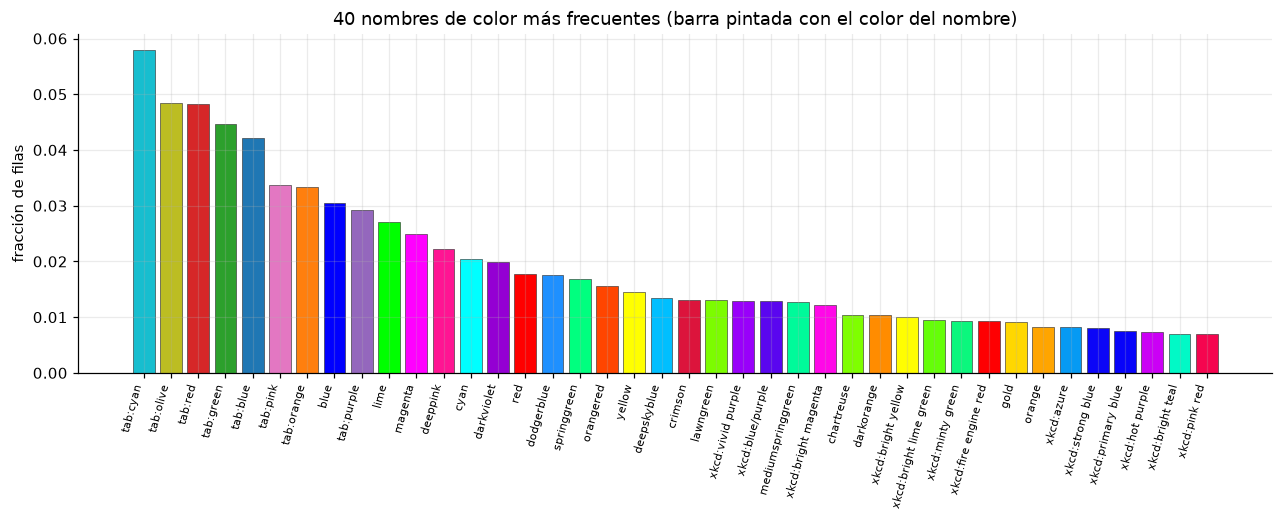

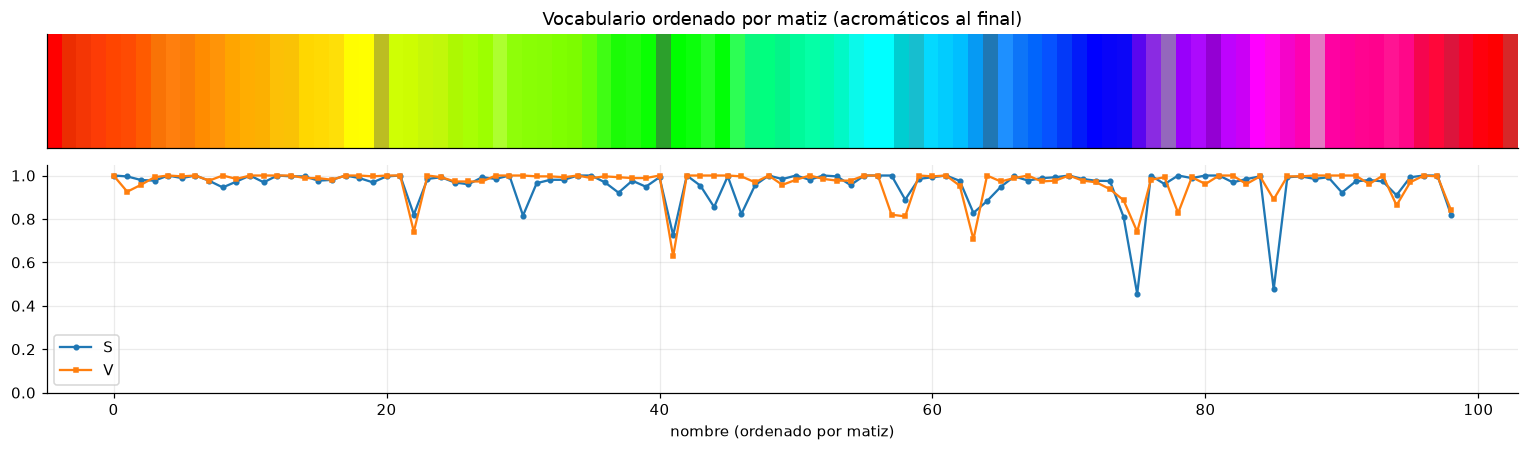

[Color] S de los nombres: mediana 0.98 [min 0.46]; V: mediana 1.00 [min 0.63]; acromáticos (S<0.15): 0.


In [12]:
top_n = min(40, len(vocab_rows))
fig, ax = plt.subplots(figsize=(14, 4))
sub = vocab_rows[:top_n]
ax.bar(range(top_n), [r["frac"] for r in sub], color=[r["hex"] or "0.5" for r in sub], edgecolor="0.2", lw=0.4)
ax.set_xticks(range(top_n), [r["nombre"] for r in sub], rotation=75, ha="right", fontsize=7)
ax.set_ylabel("fracción de filas")
ax.set_title(f"{top_n} nombres de color más frecuentes (barra pintada con el color del nombre)")
savefig(fig, "vocab_colores_top")

# Espectro completo ordenado por matiz, con S y V: ¿son todos colores saturados?
vs = sorted([r for r in vocab_rows if r["hex"]], key=lambda r: (r["s"] < 0.15, r["h"]))
fig, axes = plt.subplots(2, 1, figsize=(14, 4.2), gridspec_kw={"height_ratios": [1, 2]})
axes[0].imshow([[mcolors.to_rgb(r["hex"]) for r in vs]], aspect="auto")
axes[0].set_yticks([]); axes[0].set_xticks([]); axes[0].grid(False)
axes[0].set_title("Vocabulario ordenado por matiz (acromáticos al final)")
axes[1].plot([r["s"] for r in vs], "o-", ms=3, label="S")
axes[1].plot([r["v"] for r in vs], "s-", ms=3, label="V")
axes[1].set_ylim(0, 1.05); axes[1].legend(); axes[1].set_xlabel("nombre (ordenado por matiz)")
fig.tight_layout()
savefig(fig, "vocab_colores_espectro")
sv = np.array([[r["s"], r["v"]] for r in vs])
note("Color", f"S de los nombres: mediana {np.median(sv[:, 0]):.2f} [min {sv[:, 0].min():.2f}]; "
              f"V: mediana {np.median(sv[:, 1]):.2f} [min {sv[:, 1].min():.2f}]; "
              f"acromáticos (S<0.15): {int((sv[:, 0] < 0.15).sum())}.")

### 6.2 ¿Qué es `object_color`? Matiz latente vs matiz del nombre

Hipótesis: `object_color` es el matiz HSV en $[0,1)$ y el nombre del caption es el color con
nombre más cercano a ese matiz. Se contrastan tres reglas de asignación nombre←latente sobre
el vocabulario observado:

* **H1**: nombre con matiz más cercano en el círculo;
* **H2**: nombre más cercano en Lab a $\mathrm{HSV}(h,1,1)$;
* **H3**: nombre más cercano en Lab a $\mathrm{HSV}(h,\tilde S,\tilde V)$ con $\tilde S,\tilde V$ las medianas del vocabulario.

La regla con mayor acuerdo es la que conviene replicar en el extractor para convertir un color
dicho por el modelo en un matiz comparable.

[Color] |matiz(nombre) − object_color| en filas cromáticas (100.0%): mediana 0.0136, p95 0.0789, máx 0.1434; <0.05: 88.6% (1 unidad = 360°).
[Color] regla H1 matiz: reproduce el nombre del caption en 27.1% de las filas.
[Color] regla H2 Lab HSV(h,1,1): reproduce el nombre del caption en 26.8% de las filas.
[Color] regla H3 Lab HSV(h,0.98,1.00): reproduce el nombre del caption en 27.0% de las filas.


[Color] nombres con mayor dispersión de matiz latente (desv. circular): tab:cyan=0.052, tab:red=0.041, tab:olive=0.039.


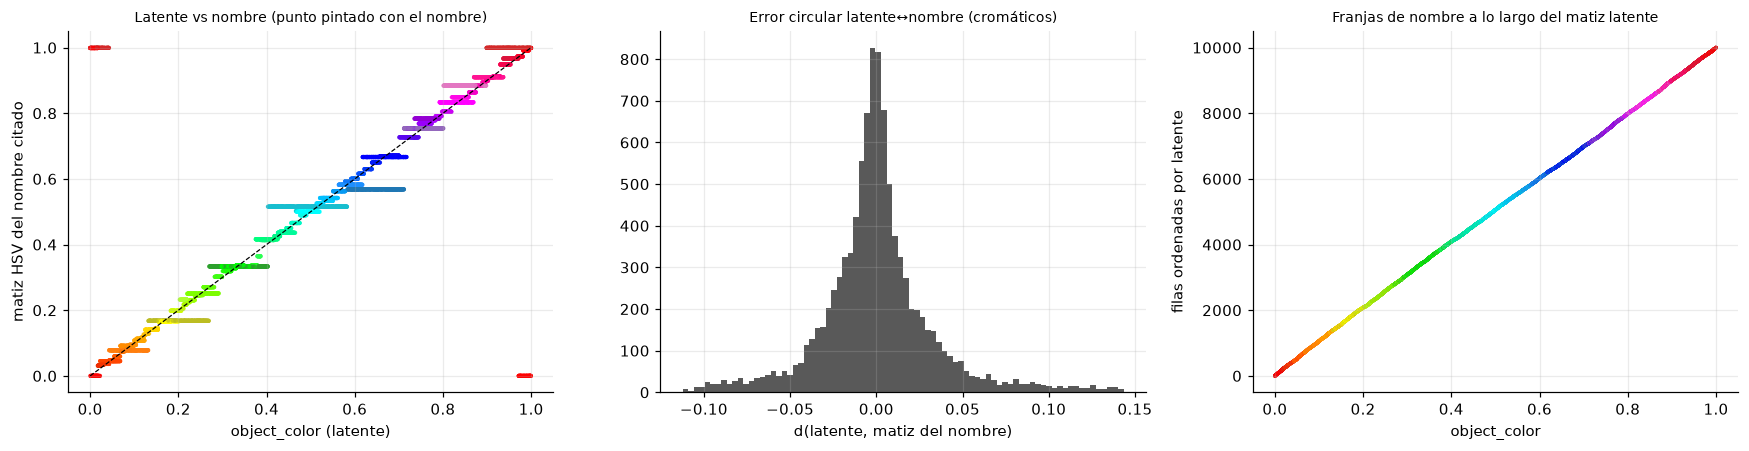

In [13]:
h_lat = A["color"].astype(float)
rgb_name = np.array([name_to_rgb(n) or (np.nan,) * 3 for n in cnames], float)
hsv_name = mcolors.rgb_to_hsv(np.nan_to_num(rgb_name))
chrom = hsv_name[:, 1] >= 0.15
d_name = circ_diff(h_lat, hsv_name[:, 0])
ad = np.abs(d_name[chrom])
note("Color", f"|matiz(nombre) − object_color| en filas cromáticas ({chrom.mean():.1%}): "
              f"mediana {np.median(ad):.4f}, p95 {np.quantile(ad, 0.95):.4f}, máx {ad.max():.4f}; "
              f"<0.05: {(ad < 0.05).mean():.1%} (1 unidad = 360°).")

vn = [r for r in vocab_rows if r["hex"]]
v_names = np.array([r["nombre"] for r in vn], dtype=object)
v_rgb = np.array([mcolors.to_rgb(r["hex"]) for r in vn])
v_hsv = mcolors.rgb_to_hsv(v_rgb)
v_lab = srgb_to_lab(v_rgb)
S_med, V_med = float(np.median(v_hsv[:, 1])), float(np.median(v_hsv[:, 2]))


def assign_hue(h):
    return v_names[np.argmin(np.abs(circ_diff(h[:, None], v_hsv[None, :, 0])), axis=1)]


def assign_lab(h, s, v):
    lab = srgb_to_lab(hsv_to_rgb(h, s, v))
    return v_names[np.argmin(((lab[:, None, :] - v_lab[None]) ** 2).sum(-1), axis=1)]


hyp = {"H1 matiz": assign_hue(h_lat),
       "H2 Lab HSV(h,1,1)": assign_lab(h_lat, 1.0, 1.0),
       f"H3 Lab HSV(h,{S_med:.2f},{V_med:.2f})": assign_lab(h_lat, S_med, V_med)}
for k, pred in hyp.items():
    note("Color", f"regla {k}: reproduce el nombre del caption en {np.mean(pred == cnames):.1%} de las filas.")

# Dispersión de matiz latente por nombre: cuánto se solapan los nombres
spread = pl.DataFrame([
    {"nombre": nm, "n": int((cnames == nm).sum()),
     "h_media": float(circ_mean(h_lat[cnames == nm])), "h_desv_circ": float(circ_std(h_lat[cnames == nm])),
     "h_min": float(h_lat[cnames == nm].min()), "h_max": float(h_lat[cnames == nm].max())}
    for nm in vc
]).sort("h_media")
amb = spread.sort("h_desv_circ", descending=True).head(3)
note("Color", "nombres con mayor dispersión de matiz latente (desv. circular): "
              + ", ".join(f"{r['nombre']}={r['h_desv_circ']:.3f}" for r in amb.to_dicts()) + ".")
spread.write_csv(TAB_DIR / f"{SPLIT}_color_nombre_vs_matiz.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax = axes[0]
ax.scatter(h_lat, hsv_name[:, 0], s=3, c=np.nan_to_num(rgb_name), alpha=0.6)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("object_color (latente)"); ax.set_ylabel("matiz HSV del nombre citado")
ax.set_title("Latente vs nombre (punto pintado con el nombre)", fontsize=9)
ax = axes[1]
ax.hist(d_name[chrom], bins=80, color="0.35")
ax.set_xlabel("d(latente, matiz del nombre)"); ax.set_title("Error circular latente↔nombre (cromáticos)", fontsize=9)
ax = axes[2]
order = np.argsort(h_lat)
ax.scatter(h_lat[order], np.arange(N), c=np.nan_to_num(rgb_name[order]), s=2)
ax.set_xlabel("object_color"); ax.set_ylabel("filas ordenadas por latente")
ax.set_title("Franjas de nombre a lo largo del matiz latente", fontsize=9)
fig.tight_layout()
savefig(fig, "color_latente_vs_nombre")

### 6.3 Términos básicos de color (nivel "relajado" de la evaluación)

Cada color se asigna al prototipo más cercano en CIELAB ($\Delta E_{76}$). Los prototipos de
abajo son los de este EDA; **si el extractor del repo usa otros, reemplázalos aquí** para que las
líneas base coincidan con la evaluación.

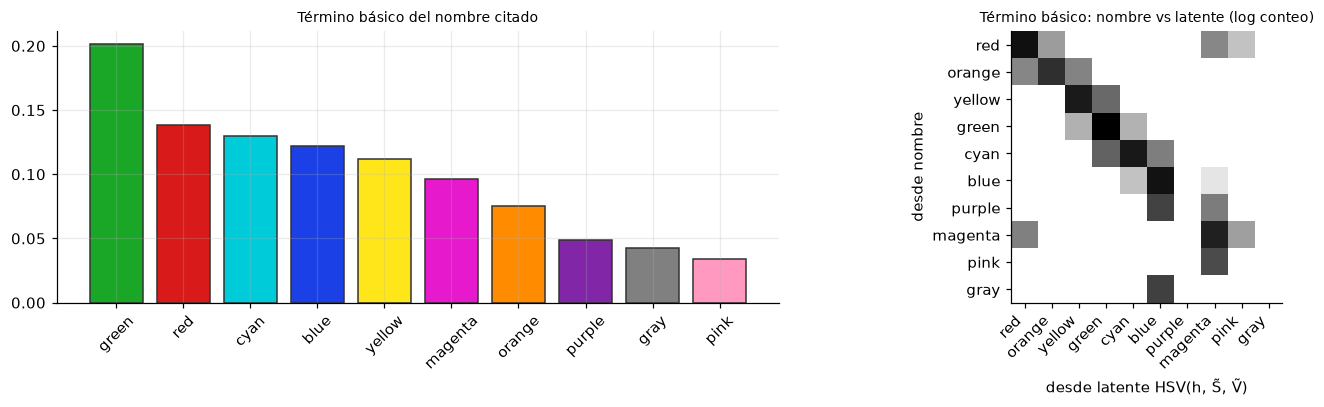

[Color] término básico (desde el nombre): green=20.1%, red=13.8%, cyan=13.0%, blue=12.2%, yellow=11.2%, magenta=9.7%, orange=7.5%, purple=4.9%, gray=4.2%, pink=3.4%; mayoritaria=20.1%, Σp²=0.124; términos nunca usados: ['black', 'white'].
[Color] acuerdo término básico nombre↔latente: 79.0% (el resto son colores frontera entre dos términos).


In [14]:
BASIC_TERMS = {
    "red": (0.85, 0.10, 0.10), "orange": (1.00, 0.55, 0.00), "yellow": (1.00, 0.90, 0.10),
    "green": (0.10, 0.65, 0.15), "cyan": (0.00, 0.80, 0.85), "blue": (0.10, 0.25, 0.90),
    "purple": (0.50, 0.15, 0.65), "magenta": (0.90, 0.10, 0.80), "pink": (1.00, 0.60, 0.75),
    "white": (1.00, 1.00, 1.00), "gray": (0.50, 0.50, 0.50), "black": (0.00, 0.00, 0.00),
}
bt_names = np.array(list(BASIC_TERMS), dtype=object)
bt_lab = srgb_to_lab(np.array(list(BASIC_TERMS.values())))


def to_basic(rgb):
    lab = srgb_to_lab(np.asarray(rgb, float))
    return bt_names[np.argmin(((lab[:, None, :] - bt_lab[None]) ** 2).sum(-1), axis=1)]


basic_name = to_basic(np.nan_to_num(rgb_name))
basic_lat = to_basic(hsv_to_rgb(h_lat, S_med, V_med))
vals, cnt = np.unique(basic_name, return_counts=True)
p = cnt / cnt.sum()
order = np.argsort(-cnt)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].bar(vals[order], p[order], color=[BASIC_TERMS[v] for v in vals[order]], edgecolor="0.2")
axes[0].set_title("Término básico del nombre citado", fontsize=9)
axes[0].tick_params(axis="x", rotation=45)
cm = np.array([[np.sum((basic_name == a) & (basic_lat == b)) for b in bt_names] for a in bt_names])
keep = cm.sum(1) + cm.sum(0) > 0
axes[1].imshow(np.log1p(cm[keep][:, keep]), cmap="Greys")
axes[1].set_xticks(range(keep.sum()), bt_names[keep], rotation=45, ha="right")
axes[1].set_yticks(range(keep.sum()), bt_names[keep])
axes[1].set_xlabel("desde latente HSV(h, S̃, Ṽ)"); axes[1].set_ylabel("desde nombre"); axes[1].grid(False)
axes[1].set_title("Término básico: nombre vs latente (log conteo)", fontsize=9)
fig.tight_layout()
savefig(fig, "color_terminos_basicos")
note("Color", "término básico (desde el nombre): "
              + ", ".join(f"{vals[i]}={p[i]:.1%}" for i in order)
              + f"; mayoritaria={p.max():.1%}, Σp²={float((p ** 2).sum()):.3f}; "
              f"términos nunca usados: {sorted(set(bt_names) - set(vals))}.")
note("Color", f"acuerdo término básico nombre↔latente: {np.mean(basic_name == basic_lat):.1%} "
              "(el resto son colores frontera entre dos términos).")

### 6.4 Fondo y foco: ¿con qué frecuencia el objeto se "camufla"?

`background_color` y `spotlight_color` no se verbalizan en el caption, pero afectan la
percepción. Una distancia de matiz objeto–fondo pequeña define casos intrínsecamente difíciles.

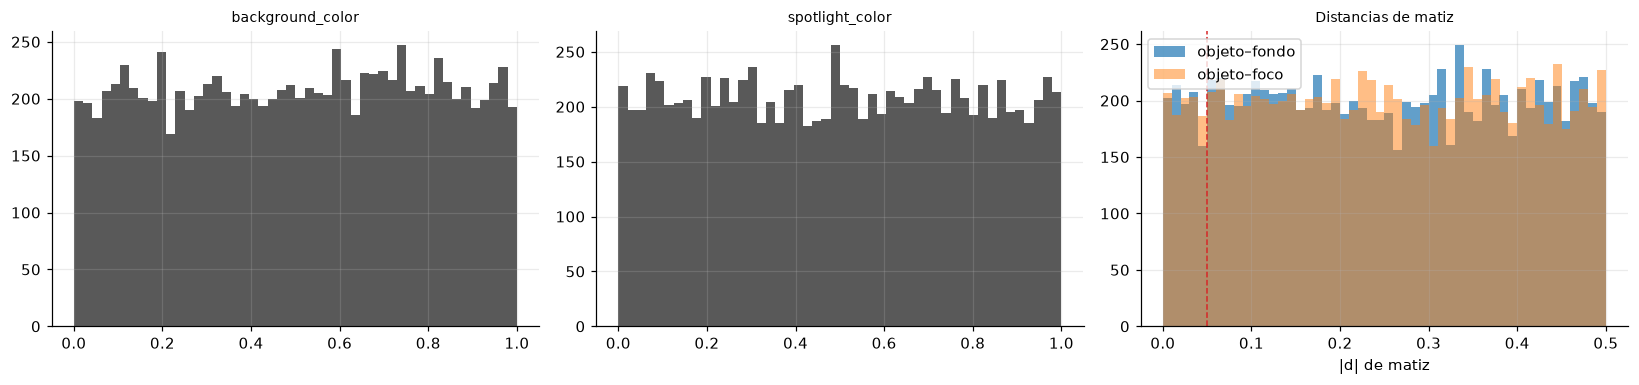

[Color] |d(objeto, fondo)| < 0.05 (≈18°): 9.8% de las filas; < 0.10: 20.2%. Bajo independencia uniforme se esperaría 10% y 20%.


In [15]:
if "bg_color" in A and "spot_color" in A:
    d_bg = np.abs(circ_diff(h_lat, A["bg_color"]))
    d_sp = np.abs(circ_diff(h_lat, A["spot_color"]))
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    for ax, k in zip(axes[:2], ("bg_color", "spot_color")):
        hh = A[k].astype(float)
        ax.hist(hh, bins=48, color="0.35")
        ax.set_title(C[k], fontsize=9)
    axes[2].hist(d_bg, bins=50, alpha=0.7, label="objeto–fondo")
    axes[2].hist(d_sp, bins=50, alpha=0.5, label="objeto–foco")
    axes[2].axvline(0.05, c="C3", ls="--", lw=1)
    axes[2].set_xlabel("|d| de matiz"); axes[2].legend(); axes[2].set_title("Distancias de matiz", fontsize=9)
    fig.tight_layout()
    savefig(fig, "color_fondo_foco")
    note("Color", f"|d(objeto, fondo)| < 0.05 (≈18°): {(d_bg < 0.05).mean():.1%} de las filas; "
                  f"< 0.10: {(d_bg < 0.10).mean():.1%}. Bajo independencia uniforme se esperaría 10% y 20%.")

## 7. Verificación a nivel de píxel (muestra de imágenes)

Para cada imagen se estima el fondo con la mediana del marco exterior y se segmenta el objeto
con píxeles de matiz cercano a `object_color` que además se alejan del fondo en Lab
($\Delta E_{76}>12$); si la máscara queda vacía se usa solo $\Delta E_{76}>30$. Del objeto se
mide el centroide normalizado $(c_x, c_y)\in[0,1]^2$ (con $c_y$ creciendo **hacia abajo**,
convención de imagen), el área relativa y el matiz circular medio. Esto permite:

1. **orientar** los códigos de posición (¿`xpos=0` es izquierda?, ¿`ypos=0` es arriba?);
2. medir qué tan **separables** son las posiciones en la imagen;
3. comprobar que `object_color` y `background_color` son matices del píxel renderizado.

In [16]:
BORDER, HUE_TOL, MIN_PIX = 6, 0.06, 30


def analyze_image(pth: Path, obj_h: float) -> dict:
    im = np.asarray(Image.open(pth).convert("RGB"), dtype=np.float32) / 255.0
    H, W, _ = im.shape
    hsv = mcolors.rgb_to_hsv(im)
    frame = np.concatenate([im[:BORDER].reshape(-1, 3), im[-BORDER:].reshape(-1, 3),
                            im[:, :BORDER].reshape(-1, 3), im[:, -BORDER:].reshape(-1, 3)])
    fhsv = mcolors.rgb_to_hsv(frame)
    bg = np.median(frame, axis=0)
    dE = np.linalg.norm(srgb_to_lab(im) - srgb_to_lab(bg), axis=-1)
    hue_ok = (np.abs(circ_diff(hsv[..., 0], obj_h)) < HUE_TOL) & (hsv[..., 1] > 0.2) & (hsv[..., 2] > 0.12)
    m, method = hue_ok & (dE > 12), "matiz+ΔE"
    if m.sum() < MIN_PIX:
        m, method = dE > 30, "ΔE"
    out = {"H": H, "W": W, "bg_hue_img": circ_mean(fhsv[fhsv[:, 1] > 0.1, 0]) if (fhsv[:, 1] > 0.1).any() else np.nan}
    if m.sum() < MIN_PIX:
        return {**out, "ok": False, "method": "falla"}
    yy, xx = np.nonzero(m)
    obj_rgb = np.median(im[m], axis=0)
    return {**out, "ok": True, "method": method, "cx": xx.mean() / W, "cy": yy.mean() / H,
            "area": float(m.mean()), "obj_hue_img": circ_mean(hsv[..., 0][m]),
            "contrast_dE": float(np.linalg.norm(srgb_to_lab(obj_rgb) - srgb_to_lab(bg)))}


if IMAGES_OK:
    samp = np.sort(rng.choice(N, size=min(N_IMG_SAMPLE, N), replace=False))
    recs = []
    for i in samp:
        pth = resolve_image(int(i))
        if pth is None:
            continue
        recs.append({"i": int(i), **analyze_image(pth, float(h_lat[i]))})
    im_df = pl.DataFrame(recs, infer_schema_length=None)
    im_df.write_csv(TAB_DIR / f"{SPLIT}_pixeles_muestra.csv")
    ok = im_df.filter(pl.col("ok"))
    sizes = Counter(zip(im_df["H"].to_list(), im_df["W"].to_list()))
    note("Píxel", f"{im_df.height} imágenes analizadas; tamaños {dict(sizes)}; "
                  f"segmentación válida {ok.height / im_df.height:.1%} "
                  f"({dict(Counter(im_df['method'].to_list()))}).")
else:
    ok = None
    note("Píxel", "imágenes no accesibles desde el manifiesto ni desde las rutas alternativas: "
                  "sección omitida (ajusta IMG_FALLBACK_DIRS).")

[Píxel] 2000 imágenes analizadas; tamaños {(224, 224): 2000}; segmentación válida 100.0% ({'matiz+ΔE': 1907, 'ΔE': 93}).


### 7.1 Orientación y separabilidad de las posiciones

[Posición] object_xpos: centroide medio por código {0: 0.297, 1: 0.496, 2: 0.68}; código 0 = izquierda y código 2 = derecha en la imagen; ρ=0.939; exactitud de un clasificador por centroide=95.9%.
[Posición] object_xpos: palabra del caption para el código de izquierda = «left», para el de derecha = «right» → CONSISTENTE con la geometría.
[Posición] object_ypos: centroide medio por código {0: 0.39, 1: 0.51, 2: 0.677}; código 0 = arriba y código 2 = abajo en la imagen; ρ=0.850; exactitud de un clasificador por centroide=85.6%.
[Posición] object_ypos: palabra del caption para el código de arriba = «top», para el de abajo = «bottom» → CONSISTENTE con la geometría.


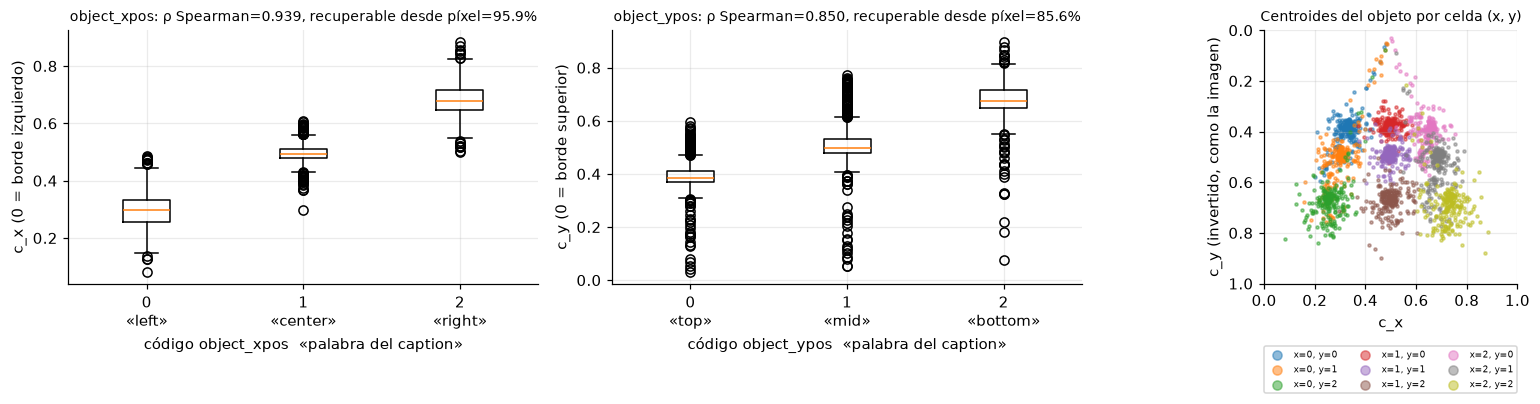

In [17]:
ORIENT = {}
if ok is not None and ok.height > 0:
    ii = ok["i"].to_numpy()
    cx, cy = ok["cx"].to_numpy(), ok["cy"].to_numpy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, k, v, lab in ((axes[0], "x", cx, "c_x (0 = borde izquierdo)"),
                          (axes[1], "y", cy, "c_y (0 = borde superior)")):
        codes = A[k][ii]
        ks = np.unique(codes)
        ax.boxplot([v[codes == c] for c in ks])
        ax.set_xticks(range(1, len(ks) + 1), [f"{c}\n«{induced.get(k, {}).get(c, '?')}»" for c in ks])
        ax.set_xlabel(f"código {C[k]}  «palabra del caption»"); ax.set_ylabel(lab)
        rho, pr = stats.spearmanr(codes, v)
        means = {int(c): float(v[codes == c].mean()) for c in ks}
        # clasificador de centroide más cercano: ¿cuánto de la posición se recupera del píxel?
        centers = np.array([means[int(c)] for c in ks])
        pred = ks[np.argmin(np.abs(v[:, None] - centers[None]), axis=1)]
        acc = float(np.mean(pred == codes))
        side = ("izquierda", "derecha") if k == "x" else ("arriba", "abajo")
        lo_code, hi_code = min(means, key=means.get), max(means, key=means.get)
        ORIENT[k] = {"means": means, "rho": rho, "acc": acc, side[0]: lo_code, side[1]: hi_code}
        ax.set_title(f"{C[k]}: ρ Spearman={rho:.3f}, recuperable desde píxel={acc:.1%}", fontsize=9)
        note("Posición", f"{C[k]}: centroide medio por código {({c: round(m, 3) for c, m in means.items()})}; "
                         f"código {lo_code} = {side[0]} y código {hi_code} = {side[1]} en la imagen; "
                         f"ρ={rho:.3f}; exactitud de un clasificador por centroide={acc:.1%}.")
        w = induced.get(k, {})
        if w:
            note("Posición", f"{C[k]}: palabra del caption para el código de {side[0]} = «{w.get(lo_code)}», "
                             f"para el de {side[1]} = «{w.get(hi_code)}» → "
                             + ("CONSISTENTE con la geometría."
                                if (w.get(lo_code) in {"left", "top", "upper"} and w.get(hi_code) in {"right", "bottom", "lower"})
                                else "revisar: la palabra no coincide con el lado observado."))
    ax = axes[2]
    cell = A["x"][ii] * 10 + A["y"][ii]
    uc = np.unique(cell)
    cmap = matplotlib.colormaps["tab10"]
    for j, c in enumerate(uc):
        sel = cell == c
        ax.scatter(cx[sel], cy[sel], s=4, alpha=0.5, color=cmap(j % 10),
                   label=f"x={c // 10}, y={c % 10}")
    ax.set_xlim(0, 1); ax.set_ylim(1, 0); ax.set_aspect("equal")
    ax.set_xlabel("c_x"); ax.set_ylabel("c_y (invertido, como la imagen)")
    ax.legend(fontsize=6, markerscale=3, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.45))
    ax.set_title("Centroides del objeto por celda (x, y)", fontsize=9)
    fig.tight_layout()
    savefig(fig, "posicion_pixel")

### 7.2 Color en el píxel y tamaño aparente

[Píxel: color y tamaño] |d(matiz píxel, object_color)|: mediana 0.0309, p95 0.0562 → object_color no coincide limpiamente con el matiz renderizado (revisar iluminación/segmentación).
[Píxel: color y tamaño] correlación sen(2π·d(foco,objeto)) vs error de matiz: r=-0.233 (p=4.1e-26).
[Píxel: color y tamaño] |d(matiz del marco, background_color)|: mediana 0.3676.


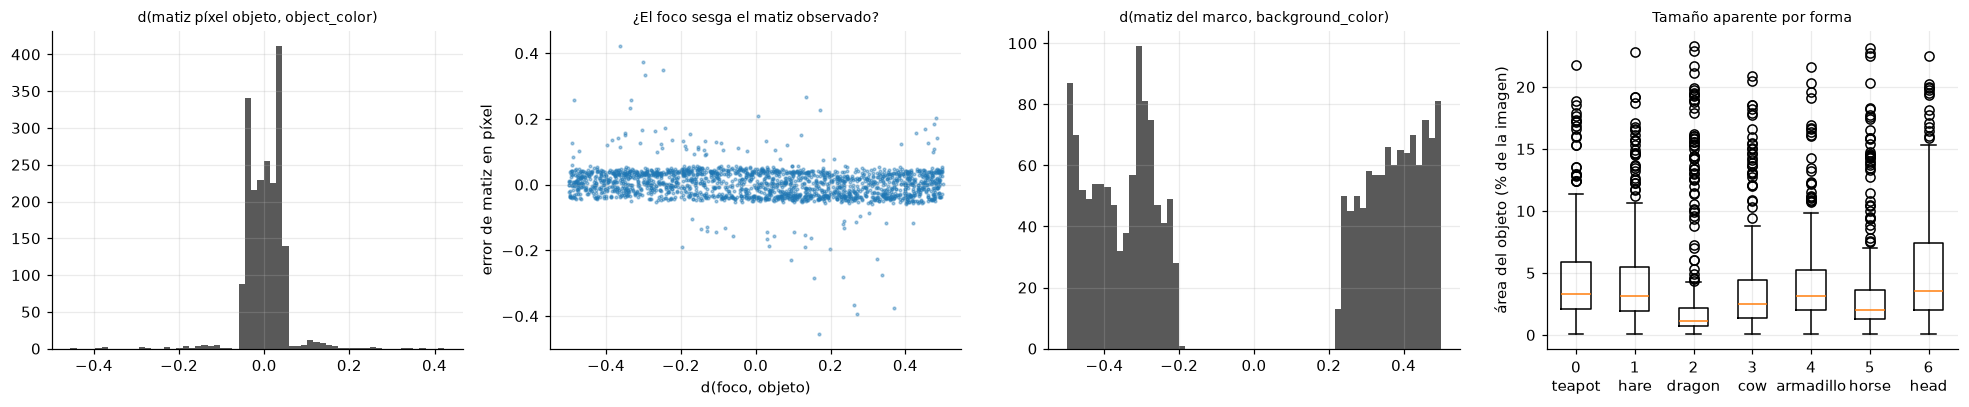

[Píxel: color y tamaño] área mediana por forma (% imagen): {0: 3.27, 1: 3.17, 2: 1.15, 3: 2.52, 4: 3.13, 5: 2.0, 6: 3.57}.
[Píxel: color y tamaño] área mediana por object_xpos: {0: 2.99, 1: 2.23, 2: 2.87} (Kruskal–Wallis p=1.4e-11) → el tamaño aparente depende de la posición (perspectiva).
[Píxel: color y tamaño] área mediana por object_ypos: {0: 1.98, 1: 2.72, 2: 4.51} (Kruskal–Wallis p=2e-37) → el tamaño aparente depende de la posición (perspectiva).
[Píxel: color y tamaño] contraste objeto–fondo ΔE76: mediana 52.5; ΔE<20 (bajo contraste): 7.0% de la muestra.


In [18]:
if ok is not None and ok.height > 0:
    ii = ok["i"].to_numpy()
    d_img = circ_diff(ok["obj_hue_img"].to_numpy(), h_lat[ii])
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
    axes[0].hist(d_img, bins=60, color="0.35")
    axes[0].set_title("d(matiz píxel objeto, object_color)", fontsize=9)
    note("Píxel: color y tamaño", f"|d(matiz píxel, object_color)|: mediana {np.median(np.abs(d_img)):.4f}, "
                  f"p95 {np.quantile(np.abs(d_img), 0.95):.4f} → object_color "
                  + ("SÍ se comporta como matiz del objeto renderizado." if np.median(np.abs(d_img)) < 0.03
                     else "no coincide limpiamente con el matiz renderizado (revisar iluminación/segmentación)."))
    if "spot_color" in A:
        axes[1].scatter(circ_diff(A["spot_color"][ii], h_lat[ii]), d_img, s=3, alpha=0.4)
        axes[1].set_xlabel("d(foco, objeto)"); axes[1].set_ylabel("error de matiz en píxel")
        axes[1].set_title("¿El foco sesga el matiz observado?", fontsize=9)
        r_sp, p_sp = stats.pearsonr(np.sin(2 * np.pi * circ_diff(A["spot_color"][ii], h_lat[ii])), d_img)
        note("Píxel: color y tamaño", f"correlación sen(2π·d(foco,objeto)) vs error de matiz: r={r_sp:.3f} (p={p_sp:.2g}).")
    if "bg_color" in A:
        bgi = im_df.filter(pl.col("i").is_in(ii.tolist()))["bg_hue_img"].to_numpy()
        d_bgi = circ_diff(bgi, A["bg_color"][ii])
        axes[2].hist(d_bgi[~np.isnan(d_bgi)], bins=60, color="0.35")
        axes[2].set_title("d(matiz del marco, background_color)", fontsize=9)
        note("Píxel: color y tamaño", f"|d(matiz del marco, background_color)|: mediana {np.nanmedian(np.abs(d_bgi)):.4f}.")
    area = ok["area"].to_numpy()
    shapes = A["shape"][ii]
    ks = np.unique(shapes)
    axes[3].boxplot([area[shapes == s] * 100 for s in ks])
    axes[3].set_xticks(range(1, len(ks) + 1), [f"{s}\n{induced.get('shape', {}).get(s, '')}" for s in ks])
    axes[3].set_ylabel("área del objeto (% de la imagen)"); axes[3].set_title("Tamaño aparente por forma", fontsize=9)
    fig.tight_layout()
    savefig(fig, "pixel_color_area")
    med_area = {int(s): float(np.median(area[shapes == s]) * 100) for s in ks}
    note("Píxel: color y tamaño", f"área mediana por forma (% imagen): {({k: round(v, 2) for k, v in med_area.items()})}.")
    for k in ("x", "y"):
        codes = A[k][ii]
        med = {int(c): round(float(np.median(area[codes == c]) * 100), 2) for c in np.unique(codes)}
        H_kw, p_kw = stats.kruskal(*[area[codes == c] for c in np.unique(codes)])
        note("Píxel: color y tamaño", f"área mediana por {C[k]}: {med} (Kruskal–Wallis p={p_kw:.2g}) → "
                      + ("el tamaño aparente depende de la posición (perspectiva)." if p_kw < 1e-3
                         else "sin efecto de perspectiva detectable."))
    con = ok["contrast_dE"].to_numpy()
    note("Píxel: color y tamaño", f"contraste objeto–fondo ΔE76: mediana {np.median(con):.1f}; "
                  f"ΔE<20 (bajo contraste): {(con < 20).mean():.1%} de la muestra.")

## 8. Entropía, líneas base y dependencias entre atributos

* $H(A)$ vs $H_{\max}=\log_2 K$ mide el desbalance.
* $\sum_k p_k^2$ es la exactitud esperada de un adivinador que respeta la marginal;
  $\max_k p_k$ la del que siempre dice la clase mayoritaria.
* Una $\mathrm{NMI}>0$ significativa entre atributos implica un **atajo**: un modelo podría acertar
  un atributo sin mirarlo, a partir de otro.

shape: (12, 7)
┌──────────────┬─────┬────────┬───────┬─────────┬─────────────┬────────┐
│ atributo     ┆ K   ┆ H_bits ┆ H_max ┆ H/H_max ┆ mayoritaria ┆ sum_p2 │
│ ---          ┆ --- ┆ ---    ┆ ---   ┆ ---     ┆ ---         ┆ ---    │
│ str          ┆ i64 ┆ f64    ┆ f64   ┆ f64     ┆ f64         ┆ f64    │
╞══════════════╪═════╪════════╪═══════╪═════════╪═════════════╪════════╡
│ forma        ┆ 7   ┆ 2.807  ┆ 2.807 ┆ 1.000   ┆ 0.145       ┆ 0.143  │
│ xpos         ┆ 3   ┆ 1.584  ┆ 1.585 ┆ 1.000   ┆ 0.343       ┆ 0.334  │
│ ypos         ┆ 3   ┆ 1.585  ┆ 1.585 ┆ 1.000   ┆ 0.339       ┆ 0.333  │
│ color_nombre ┆ 99  ┆ 5.954  ┆ 6.629 ┆ 0.898   ┆ 0.058       ┆ 0.023  │
│ color_basico ┆ 10  ┆ 3.144  ┆ 3.322 ┆ 0.946   ┆ 0.201       ┆ 0.124  │
│ fondo_12bins ┆ 12  ┆ 3.584  ┆ 3.585 ┆ 1.000   ┆ 0.091       ┆ 0.083  │
│ foco_12bins  ┆ 12  ┆ 3.585  ┆ 3.585 ┆ 1.000   ┆ 0.085       ┆ 0.083  │
│ foco_pos_q8  ┆ 8   ┆ 3.000  ┆ 3.000 ┆ 1.000   ┆ 0.125       ┆ 0.125  │
│ rot_alpha_q8 ┆ 8   ┆ 3.000  ┆ 3.00

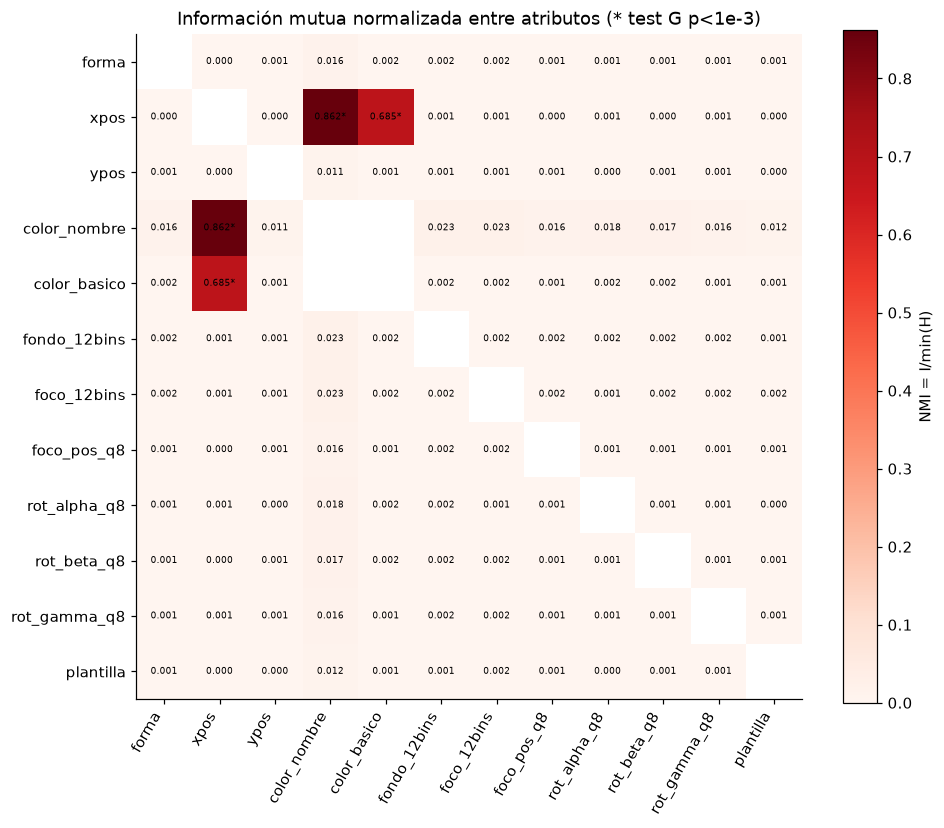

[Dependencias] pares con dependencia significativa y no trivial (p<1e-3, I−sesgo>0.01 bits): xpos–color_nombre: I=1.365 bits (sesgo≈0.014); xpos–color_basico: I=1.085 bits (sesgo≈0.001)


In [19]:
D = {}
for k, lab in (("shape", "forma"), ("x", "xpos"), ("y", "ypos")):
    if k in A:
        D[lab] = A[k]
D["color_nombre"] = cnames
D["color_basico"] = basic_name
if "bg_color" in A:
    D["fondo_12bins"] = hue_bins(A["bg_color"])
if "spot_color" in A:
    D["foco_12bins"] = hue_bins(A["spot_color"])
if "spot_pos" in A:
    D["foco_pos_q8"] = quantile_bins(A["spot_pos"])
for k, lab in (("rot_a", "rot_alpha_q8"), ("rot_b", "rot_beta_q8"), ("rot_g", "rot_gamma_q8")):
    if k in A:
        D[lab] = quantile_bins(A[k])
if "phrasing" in A:
    D["plantilla"] = A["phrasing"]

ent_rows = []
for k, v in D.items():
    vals, cnt = np.unique(v, return_counts=True)
    p = cnt / cnt.sum()
    ent_rows.append({"atributo": k, "K": len(vals), "H_bits": entropy_bits(v), "H_max": np.log2(len(vals)),
                     "H/H_max": entropy_bits(v) / np.log2(len(vals)) if len(vals) > 1 else np.nan,
                     "mayoritaria": float(p.max()), "sum_p2": float((p ** 2).sum())})
ent = pl.DataFrame(ent_rows)
with pl.Config(tbl_rows=30, float_precision=3):
    print(ent)
ent.write_csv(TAB_DIR / f"{SPLIT}_entropia_lineas_base.csv")

described = [r for r in ent_rows if r["atributo"] in ("forma", "xpos", "ypos", "color_basico")]
note("Líneas base", "por atributo descrito: "
                    + "; ".join(f"{r['atributo']}: K={r['K']}, H/Hmax={r['H/H_max']:.3f}, "
                                f"Σp²={r['sum_p2']:.3f}, mayoritaria={r['mayoritaria']:.3f}" for r in described))
note("Líneas base", f"exactitud macro por azar (media Σp² sobre forma, x, y, color básico) = "
                    f"{np.mean([r['sum_p2'] for r in described]):.3f}; con clase mayoritaria = "
                    f"{np.mean([r['mayoritaria'] for r in described]):.3f}.")

keys = list(D)
nk = len(keys)
NMI = np.full((nk, nk), np.nan)
PV = np.ones((nk, nk))
flag = []
for i in range(nk):
    for j in range(nk):
        if i == j:
            continue
        if keys[i] == "color_nombre" and keys[j] == "color_basico" or keys[j] == "color_nombre" and keys[i] == "color_basico":
            continue  # uno es función del otro
        mi, pv, bias = mutual_info_bits(D[keys[i]], D[keys[j]])
        hmin = min(entropy_bits(D[keys[i]]), entropy_bits(D[keys[j]]))
        NMI[i, j] = mi / hmin if hmin > 0 else np.nan
        PV[i, j] = pv
        if i < j and pv < 1e-3 and mi - bias > 0.01:
            flag.append((keys[i], keys[j], mi, bias, pv))

fig, ax = plt.subplots(figsize=(9, 7.5))
imh = ax.imshow(NMI, cmap="Reds", vmin=0, vmax=max(0.05, np.nanmax(NMI)))
for (i, j), v in np.ndenumerate(NMI):
    if not np.isnan(v):
        ax.text(j, i, f"{v:.3f}" + ("*" if PV[i, j] < 1e-3 else ""), ha="center", va="center", fontsize=6)
ax.set_xticks(range(nk), keys, rotation=60, ha="right"); ax.set_yticks(range(nk), keys); ax.grid(False)
fig.colorbar(imh, ax=ax, label="NMI = I/min(H)")
ax.set_title("Información mutua normalizada entre atributos (* test G p<1e-3)")
fig.tight_layout()
savefig(fig, "informacion_mutua")
note("Dependencias", "pares con dependencia significativa y no trivial (p<1e-3, I−sesgo>0.01 bits): "
                     + ("; ".join(f"{a}–{b}: I={mi:.3f} bits (sesgo≈{bi:.3f})" for a, b, mi, bi, _ in flag)
                        if flag else "ninguno → no hay atajos entre atributos."))

## 9. Plantillas de caption

shape: (5, 7)
┌───────────┬──────┬───────┬────────────────┬───────────────────┬───────────────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────┐
│ plantilla ┆ n    ┆ frac  ┆ palabras_media ┆ menciona_posicion ┆ nombre_entre_comillas ┆ ejemplo                                                                                         │
│ ---       ┆ ---  ┆ ---   ┆ ---            ┆ ---               ┆ ---                   ┆ ---                                                                                             │
│ i64       ┆ i64  ┆ f64   ┆ f64            ┆ f64               ┆ f64                   ┆ str                                                                                             │
╞═══════════╪══════╪═══════╪════════════════╪═══════════════════╪═══════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════╡
│ 0         ┆ 2019 ┆ 0.202 ┆ 15.993         ┆ 

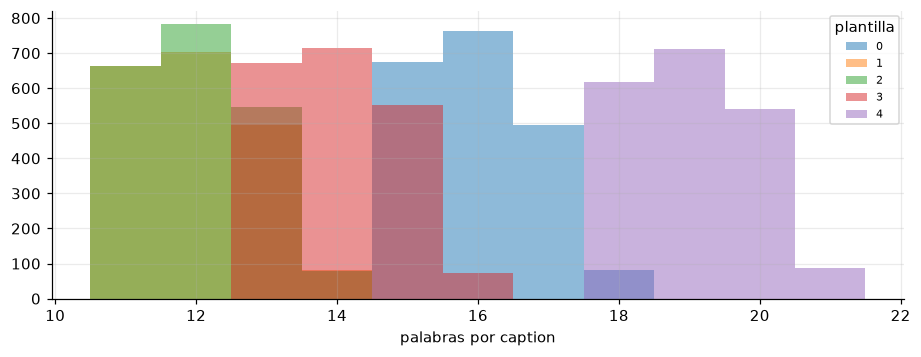

In [20]:
if "phrasing" in A:
    ph = A["phrasing"]
    lens = np.array([len(TOK_RE.findall(c)) for c in caps_l])
    has_pos = np.array([bool(t & POS_WORDS) for t in toks])
    rows = []
    for v in np.unique(ph):
        sel = ph == v
        rows.append({"plantilla": v, "n": int(sel.sum()), "frac": float(sel.mean()),
                     "palabras_media": float(lens[sel].mean()), "menciona_posicion": float(has_pos[sel].mean()),
                     "nombre_entre_comillas": float(has_q[sel].mean()),
                     "ejemplo": caps[int(np.flatnonzero(sel)[0])]})
    tpl = pl.DataFrame(rows)
    with pl.Config(tbl_rows=30, fmt_str_lengths=110, tbl_width_chars=200, float_precision=3):
        print(tpl)
    tpl.write_csv(TAB_DIR / f"{SPLIT}_plantillas.csv")
    note("Caption", f"{len(rows)} plantillas; longitud {lens.min()}–{lens.max()} palabras (media {lens.mean():.1f}); "
                    f"captions que mencionan posición: {has_pos.mean():.1%}.")
    fig, ax = plt.subplots(figsize=(10, 3.4))
    for v in np.unique(ph):
        ax.hist(lens[ph == v], bins=np.arange(lens.min(), lens.max() + 2) - 0.5, alpha=0.5, label=str(v))
    ax.set_xlabel("palabras por caption"); ax.legend(title="plantilla", fontsize=7)
    savefig(fig, "caption_longitud")

## 10. Comparación con train / val

Divergencia de Jensen–Shannon (bits, $\in[0,1]$) para atributos discretos y KS de dos muestras
para latentes continuos. Se revisa además si test contiene nombres de color ausentes en train.

In [21]:
cmp_rows = []
need = [C[k] for k in ("shape", "x", "y", "color", "bg_color", "spot_color", "spot_pos", "rot_a", "cname", "phrasing") if C[k]]
for sp in SPLITS_CMP:
    pth = MANIFEST_DIR / f"m3di_{sp}.parquet"
    if not pth.is_file():
        print(f"{pth.name} no existe, se omite")
        continue
    o = pl.read_parquet(pth, columns=need)
    for k in ("shape", "x", "y", "cname", "phrasing"):
        if C[k]:
            cmp_rows.append({"split": sp, "atributo": C[k], "tipo": "JSD bits",
                             "valor": jsd_bits(df[C[k]].to_numpy(), o[C[k]].to_numpy()), "p": None})
    for k in ("color", "bg_color", "spot_color", "spot_pos", "rot_a"):
        if C[k]:
            Dks, pks = stats.ks_2samp(df[C[k]].to_numpy(), o[C[k]].to_numpy())
            cmp_rows.append({"split": sp, "atributo": C[k], "tipo": "KS D", "valor": float(Dks), "p": float(pks)})
    unseen = set(vc) - set(o[C["cname"]].unique().to_list())
    note("Splits", f"{sp}: {o.height} filas; nombres de color de {SPLIT} ausentes en {sp}: "
                   f"{len(unseen)} {sorted(unseen)[:5]}.")
if cmp_rows:
    cmpdf = pl.DataFrame(cmp_rows)
    with pl.Config(tbl_rows=40, float_precision=4):
        print(cmpdf)
    cmpdf.write_csv(TAB_DIR / f"{SPLIT}_vs_splits.csv")
    wj = cmpdf.filter(pl.col("tipo") == "JSD bits").sort("valor", descending=True).row(0, named=True)
    note("Splits", f"máxima JSD en atributos discretos: {wj['atributo']} vs {wj['split']} = {wj['valor']:.4f} bits "
                   "(< 0.01 ⇒ distribuciones prácticamente idénticas).")
    ks_rows = cmpdf.filter(pl.col("tipo") == "KS D")
    if ks_rows.height:
        wk = ks_rows.sort("valor", descending=True).row(0, named=True)
        note("Splits", f"máximo KS en latentes continuos: {wk['atributo']} vs {wk['split']} D={wk['valor']:.4f} "
                       f"(p={wk['p']:.3g}); {int((ks_rows['p'] < 0.001).sum())}/{ks_rows.height} pruebas con p<0.001.")

m3di_train.parquet no existe, se omite
m3di_val.parquet no existe, se omite


## 11. Inspección visual

### 11.1 Grilla de posiciones
Las filas y columnas se ordenan según la **geometría observada** (sección 7.1), no según el
código; el título indica el código y la palabra inducida del caption. Si la grilla se ve como
una matriz 3×3 coherente, el mapeo código→lado está verificado a ojo.

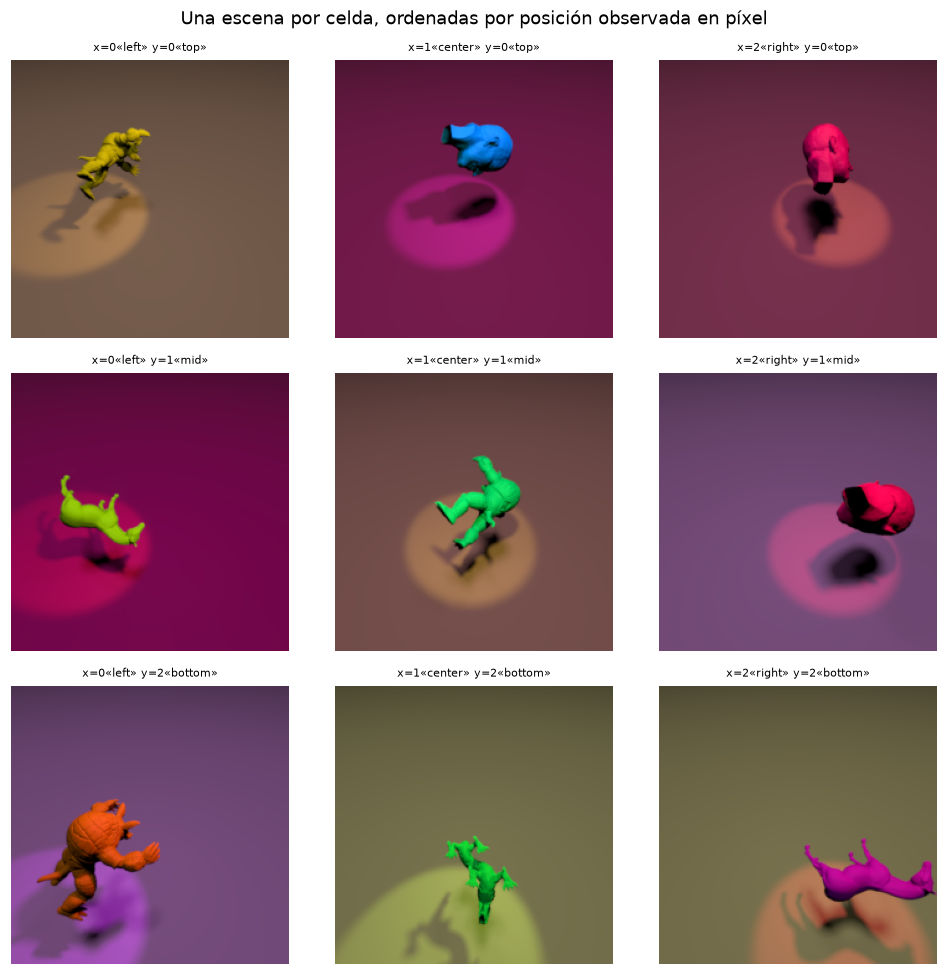

In [22]:
def show(ax, i, title=None):
    pth = resolve_image(int(i))
    if pth is not None:
        ax.imshow(Image.open(pth).convert("RGB"))
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_frame_on(False)
    if title:
        ax.set_title(title, fontsize=7)


if IMAGES_OK and "x" in A and "y" in A:
    xs_sorted = sorted(np.unique(A["x"]), key=lambda c: ORIENT.get("x", {}).get("means", {}).get(int(c), c))
    ys_sorted = sorted(np.unique(A["y"]), key=lambda c: ORIENT.get("y", {}).get("means", {}).get(int(c), c))
    fig, axes = plt.subplots(len(ys_sorted), len(xs_sorted), figsize=(3 * len(xs_sorted), 3 * len(ys_sorted)))
    for r, yv in enumerate(ys_sorted):
        for c, xv in enumerate(xs_sorted):
            pool = np.flatnonzero((A["x"] == xv) & (A["y"] == yv))
            i = int(rng.choice(pool))
            show(axes[r, c], i, f"x={xv}«{induced.get('x', {}).get(xv, '')}» "
                                f"y={yv}«{induced.get('y', {}).get(yv, '')}»")
    fig.suptitle("Una escena por celda, ordenadas por posición observada en píxel")
    fig.tight_layout()
    savefig(fig, "grilla_posiciones")

### 11.2 Formas y términos básicos de color

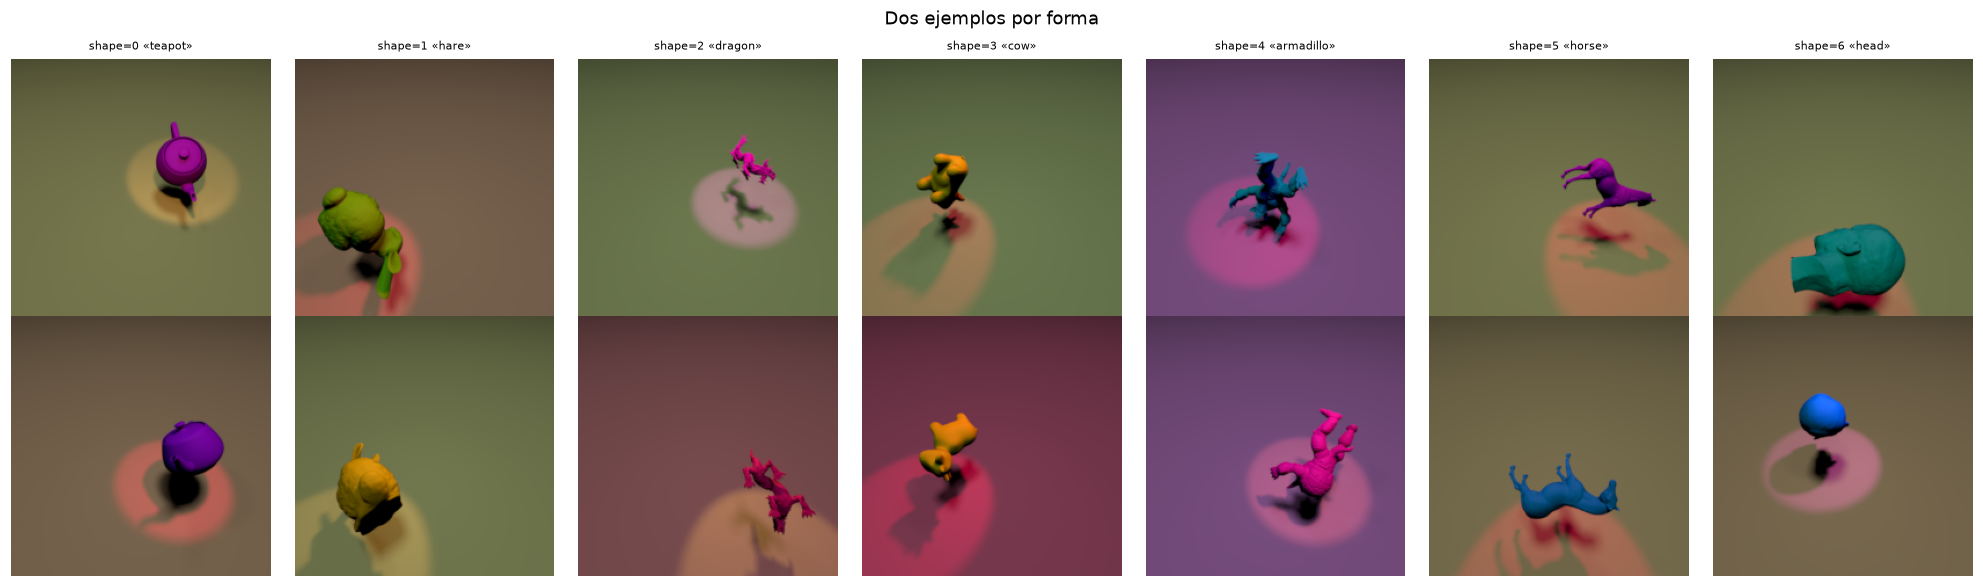

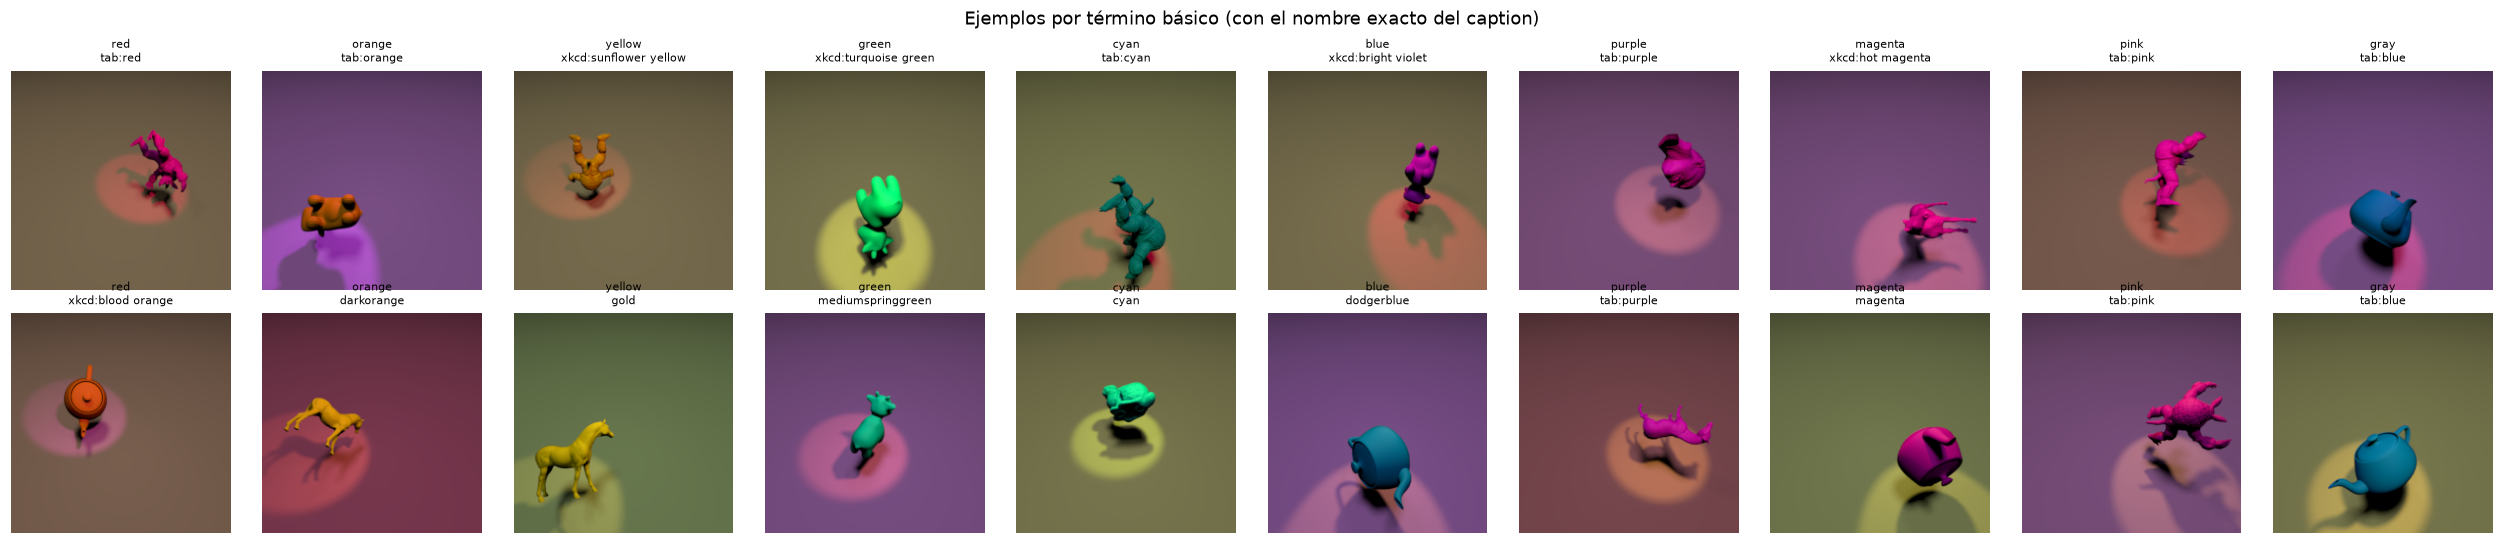

In [23]:
if IMAGES_OK:
    ks = np.unique(A["shape"])
    fig, axes = plt.subplots(2, len(ks), figsize=(2.6 * len(ks), 5.4))
    for j, s in enumerate(ks):
        for r in range(2):
            i = int(rng.choice(np.flatnonzero(A["shape"] == s)))
            show(axes[r, j], i, f"shape={s} «{induced.get('shape', {}).get(s, '')}»" if r == 0 else None)
    fig.suptitle("Dos ejemplos por forma")
    fig.tight_layout()
    savefig(fig, "galeria_formas")

    used = [t for t in bt_names if np.any(basic_name == t)]
    fig, axes = plt.subplots(2, len(used), figsize=(2.3 * len(used), 5))
    axes = np.atleast_2d(axes).reshape(2, -1)
    for j, t in enumerate(used):
        for r in range(2):
            i = int(rng.choice(np.flatnonzero(basic_name == t)))
            show(axes[r, j], i, f"{t}\n{cnames[i]}")
    fig.suptitle("Ejemplos por término básico (con el nombre exacto del caption)")
    fig.tight_layout()
    savefig(fig, "galeria_colores")

### 11.3 Casos difíciles: bajo contraste y segmentación fallida

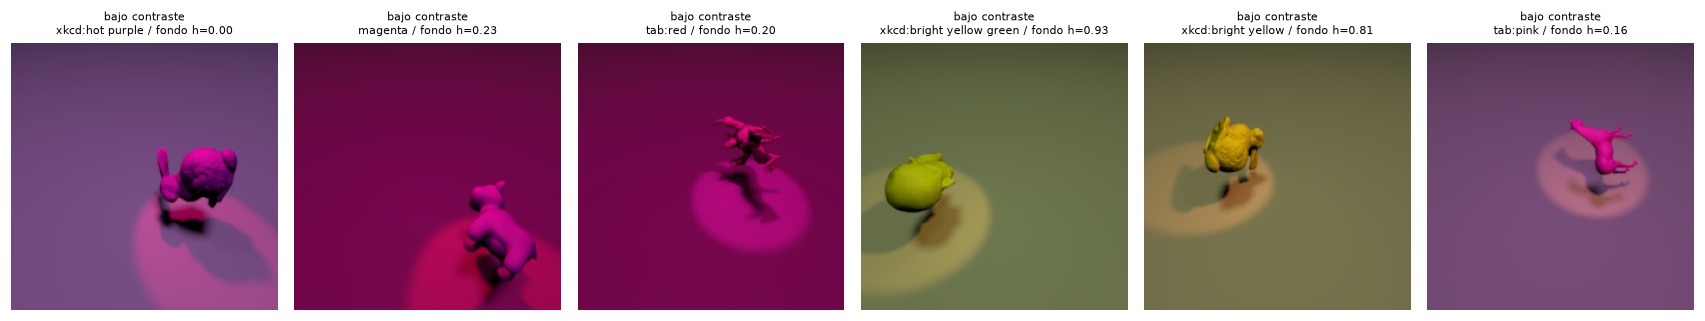

In [24]:
if ok is not None and ok.height > 0:
    hard = ok.sort("contrast_dE").head(6)["i"].to_list()
    fail = im_df.filter(~pl.col("ok"))["i"].to_list()[:6]
    sel = [(i, "bajo contraste") for i in hard] + [(i, "segm. fallida") for i in fail]
    fig, axes = plt.subplots(1, len(sel), figsize=(2.6 * len(sel), 3.2))
    for ax, (i, why) in zip(np.atleast_1d(axes), sel):
        show(ax, i, f"{why}\n{cnames[i]} / fondo h={A['bg_color'][i]:.2f}" if "bg_color" in A else why)
    fig.tight_layout()
    savefig(fig, "casos_dificiles")

## 12. Resumen de hallazgos

Se imprime y se guarda en `reports/tables/eda/hallazgos_<split>.md`, listo para pegar en el informe.

In [25]:
lines = [f"# Hallazgos del EDA — M3DI `{SPLIT}` ({N} escenas)\n"]
current = None
for sec, txt in FINDINGS:
    if sec != current:
        lines.append(f"\n## {sec}\n")
        current = sec
    lines.append(f"- {txt}")
out_md = TAB_DIR / f"hallazgos_{SPLIT}.md"
out_md.write_text("\n".join(lines) + "\n", encoding="utf-8")
print("\n".join(lines))
print(f"\n→ {out_md}")

# Hallazgos del EDA — M3DI `test` (10000 escenas)


## Integridad

- 10000 filas, 25 columnas; nulos/NaN: ninguno.
- image_id únicos: 10000/10000 ✓
- row_idx contiguo 0..N-1: True; en orden: True.
- número del archivo de imagen crece con row_idx: True (condición para la alineación imagen↔fila).
- captions únicos: 5385/10000 (53.8%); las repeticiones son esperables en texto generado por plantillas.
- imágenes accesibles (muestra de 200): 100.0% (vía image_path directo: 0.0%).

## Imagen vs texto

- object_shape: 0.00% de desacuerdo.
- object_xpos: 0.00% de desacuerdo.
- object_ypos: 0.00% de desacuerdo.
- object_zpos: 0.00% de desacuerdo.

## Latentes

- object_zpos es constante (0): se excluye de la evaluación.
- latentes en [0,1]: ['object_alpharot', 'object_betarot', 'object_gammarot', 'object_color', 'spotlight_pos', 'spotlight_color', 'background_color'].
- object_alpharot: rango [0.000, 1.000], KS D=0.007 vs uniforme.
- object_betarot: rango [0.000, 1.000], KS D=0.009 vs uniforme.